# Profiling Gaya Bermain Pemain LCK — K-Means Clustering Berbasis Data Multi-Regional
**Versi 2.** Perbaikan atas versi sebelumnya:

| Aspek | Versi lama | Versi ini | Alasan |
|---|---|---|---|
| Jumlah fitur | 5 | 12 | 5 fitur lama saling berkorelasi (r sampai 0.75) sehingga PC1 menyerap 42–56% variansi → yang terukur kualitas, bukan gaya |
| Normalisasi | Z per liga+role | **Z global per role** | Z per liga menghapus perbedaan antar-liga *by construction*, membuat RM#4 tidak terjawab |
| Ruang clustering | 5 fitur mentah | PCA (retensi 80% variansi) | Denoising, rasio n:p lebih sehat |
| Pemilihan K | Elbow saja | Elbow + Silhouette + DB + CH + Gap Statistic + **stabilitas bootstrap ARI** | Elbow & silhouette saling bertentangan di versi lama tanpa aturan tie-break |
| Pembanding | — | Ward hierarchical + GMM | Menjawab "kenapa K-Means?" |
| Validasi domain | — | **Champion pool lift** per cluster | RM#3 menjanjikan validasi domain tapi belum ada mekanismenya |
| Analisis region | — | Uji chi-square + permutasi liga × cluster | Jawaban langsung RM#4 |

**Catatan data penting:** seluruh 6.190 baris LPL berstatus `datacompleteness = "partial"` sehingga tidak memiliki kolom `golddiffat15`, `xpdiffat15`, `csdiffat15`, `damagemitigatedperminute`, `damagetotowers`, dan `monsterkillsownjungle`/`monsterkillsenemyjungle`. Karena LPL termasuk dalam ruang lingkup penelitian, 12 fitur utama disusun **hanya dari kolom yang lengkap di keenam liga**. Fitur tempo (`at15`) diuji terpisah pada Lampiran B.



## 0. Setup

In [1]:
import warnings, itertools
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score, adjusted_rand_score)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

In [2]:
DATA_PATH      = "oracles_elixir_2025.csv"
TIER1_LEAGUES  = ["LCK", "LPL", "LEC", "LCP", "LTA N", "LTA S"]
TARGET_YEAR    = 2025
FOCUS_LEAGUE   = "LCK"
ROLES          = ["top", "jng", "mid", "bot", "sup"]
MIN_GAMES      = 10
PCA_VAR_TARGET = 0.80    # proporsi variansi yang dipertahankan untuk ruang clustering
K_RANGE        = range(2, 9)
K_MIN_MEANING  = 3       # K=2 dianggap terlalu kasar untuk profiling
ARI_THRESHOLD  = 0.60    # ambang stabilitas bootstrap
N_BOOTSTRAP    = 100
BOOT_FRAC      = 0.80

# Override manual bila hasil aturan otomatis dinilai kurang interpretable secara domain.
# Kosongkan ({}) untuk memakai hasil aturan sepenuhnya. Setiap override WAJIB dijustifikasi
# di naskah -- misalnya: "K=4 dipilih meskipun aturan menunjuk K=3 karena cluster keempat
# memiliki champion pool yang jelas berbeda (assassin) dan bermakna secara domain."
K_OVERRIDE = {}   # contoh: {"sup": 4}

In [3]:
CLUSTER_NAMES = {
    "top_0": "Penahan Utilitas",
    "top_1": "Pengumpul Sumber Daya Mandiri",
    "top_2": "Penuntas Bersumber Daya Tinggi",
    "top_3": "Garda Depan Ofensif",

    "jng_0": "Fasilitator Bersumber Daya Rendah",
    "jng_1": "Penyerbu Agresif",
    "jng_2": "Pengumpul Sumber Daya Terkendali",

    "mid_0": "Fasilitator Utilitas",
    "mid_1": "Penuntas Berisiko Tinggi",
    "mid_2": "Penyeimbang Terkendali",
    "mid_3": "Penghasil Kerusakan Mandiri",
    "mid_4": "Poros Serangan Dominan",

    "bot_0": "Penopang Bersumber Daya Rendah",
    "bot_1": "Penyerang Seimbang",
    "bot_2": "Poros Serangan Utama",

    "sup_0": "Inisiator Garda Depan",
    "sup_1": "Penyergap Mandiri",
    "sup_2": "Fasilitator Terkendali",
    "sup_3": "Pengendali Penglihatan",
}

In [4]:
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print("Baris mentah:", f"{df_raw.shape[0]:,}", "| Kolom:", df_raw.shape[1])
print("Liga tersedia:", len(df_raw["league"].dropna().unique()), "liga")

Baris mentah: 120,492 | Kolom: 165
Liga tersedia: 45 liga


In [5]:
d = df_raw[df_raw["league"].isin(TIER1_LEAGUES) & (df_raw["year"] == TARGET_YEAR)].copy()
print(f"Setelah filter liga Tier 1 + tahun {TARGET_YEAR}: {d.shape[0]:,}")

d = d[d["playoffs"] == 0]
d = d[~((d["league"] == "LCK") & (d["split"] == "Cup"))]
print(f"Setelah buang playoffs & LCK Cup           : {d.shape[0]:,}")

d = d[d["position"] != "team"]
print(f"Setelah buang baris ringkasan tim          : {d.shape[0]:,}")

print()
print("Split yang tercakup per liga:")
print(d.groupby("league")["split"].unique().to_string())

Setelah filter liga Tier 1 + tahun 2025: 27,864
Setelah buang playoffs & LCK Cup           : 20,364
Setelah buang baris ringkasan tim          : 16,970

Split yang tercakup per liga:
league
LCK                             [Rounds 1-2, Rounds 3-5]
LCP                          [Split 1, Split 2, Split 3]
LEC                             [Winter, Spring, Summer]
LPL      [Split 1, Split 2 Placements, Split 2, Split 3]
LTA N                        [Split 1, Split 2, Split 3]
LTA S                        [Split 1, Split 2, Split 3]


In [6]:
print(pd.crosstab(d["league"], d["datacompleteness"]).to_string())

partial_only_cols = ["golddiffat15", "xpdiffat15", "csdiffat15",
                     "damagemitigatedperminute", "damagetotowers",
                    "monsterkillsownjungle", "monsterkillsenemyjungle"]
print()
print("Persentase missing per liga untuk kolom yang tidak universal:")
print((d.groupby("league")[partial_only_cols].apply(lambda x: x.isna().mean() * 100).round(1)).to_string())
print()
print(">> Kolom di atas TIDAK dipakai sebagai fitur utama karena hilang total di salah satu liga.")

datacompleteness  complete  partial
league                             
LCK                   3670        0
LCP                   1890        0
LEC                   1980        0
LPL                      0     6190
LTA N                 1590        0
LTA S                 1650        0

Persentase missing per liga untuk kolom yang tidak universal:
        golddiffat15  xpdiffat15  csdiffat15  damagemitigatedperminute  damagetotowers  monsterkillsownjungle  monsterkillsenemyjungle
league                                                                                                                                
LCK              0.0         0.0         0.0                       0.0             0.0                  100.0                    100.0
LCP              0.0         0.0         0.0                       0.0             0.0                  100.0                    100.0
LEC              0.0         0.0         0.0                       0.0             0.0                  100.0

In [7]:
# Pada tahap ini satu baris masih berarti "satu pemain pada satu game".

d["mins"]          = d["gamelength"] / 60.0     # durasi disimpan dalam detik
d["kills_assists"] = d["kills"] + d["assists"]  # dipakai sbg pembilang & penyebut

# JALUR 1 - sudah tersedia di dataset, dipakai apa adanya lalu dirata-ratakan.
#           kunci = nama variabel, nilai = nama kolom pada dataset.
KOLOM_SIAP_PAKAI = {
    "dpm":             "dpm",
    "damageshare":     "damageshare",
    "earnedgoldshare": "earnedgoldshare",
    "cspm":            "cspm",
    "dmg_taken_pm":    "damagetakenperminute",
    "wpm":             "wpm",
    "wcpm":            "wcpm",
}

# JALUR 2 - tidak tersedia di dataset, dihitung sbg rasio dari jumlah.
#           kunci = nama variabel, nilai = (kolom pembilang, kolom penyebut).
VARIABEL_TURUNAN = {
    "jungle_cs_share": ("monsterkills",  "total cs"),
    "deaths_pm":       ("deaths",        "mins"),
    "death_share":     ("deaths",        "teamdeaths"),
    "kp":              ("kills_assists", "teamkills"),
    "kill_ratio":      ("kills",         "kills_assists"),
}

# urutan mengikuti Tabel 2.1 pada naskah (dikelompokkan menurut dimensi gaya)
FEATURES = ["dpm", "damageshare",                      # keluaran serangan
            "earnedgoldshare", "cspm", "jungle_cs_share",   # sumber daya ekonomi
            "deaths_pm", "death_share",                # pengambilan risiko
            "dmg_taken_pm", "kp", "kill_ratio",        # posisi dalam benturan tim
            "wpm", "wcpm"]                             # penguasaan penglihatan

assert set(FEATURES) == set(KOLOM_SIAP_PAKAI) | set(VARIABEL_TURUNAN)
print(f"{len(KOLOM_SIAP_PAKAI)} variabel diambil langsung dari dataset")
print(f"{len(VARIABEL_TURUNAN)} variabel diturunkan sendiri")
print()
print("Bukti penyebut kecil yang mendasari pilihan rasio-dari-jumlah:")
for kol in ["teamkills", "kills_assists"]:
    q = d[kol]
    print(f"  {kol:<14} median={q.median():>5.0f}  persentil-10={q.quantile(.10):>4.0f}  "
          f"proporsi <= 3: {(q <= 3).mean() * 100:>5.1f}%")

7 variabel diambil langsung dari dataset
5 variabel diturunkan sendiri

Bukti penyebut kecil yang mendasari pilihan rasio-dari-jumlah:
  teamkills      median=   14  persentil-10=   5  proporsi <= 3:   6.0%
  kills_assists  median=   10  persentil-10=   3  proporsi <= 3:  14.9%


In [8]:
KEY = ["playerid", "league", "position"]      # unit analisis
g = d.groupby(KEY)

agg = pd.DataFrame(index=g.size().index)
agg["n_games"] = g.size()

# JALUR 1: rata-rata nilai kolom antar-pertandingan
for nama, kolom in KOLOM_SIAP_PAKAI.items():
    agg[nama] = g[kolom].mean()

# JALUR 2: jumlahkan pembilang & penyebut dulu, baru bagi
for nama, (pembilang, penyebut) in VARIABEL_TURUNAN.items():
    agg[nama] = g[pembilang].sum() / g[penyebut].sum().replace(0, np.nan)

# label identitas, diambil dari game terakhir (tim bisa berubah di tengah musim)
agg["playername"] = g["playername"].last()
agg["teamname"]   = g["teamname"].last()
agg = agg.reset_index()

print("Satu baris = satu pemain, pada satu liga, pada satu peran.")
print("Jumlah unit analisis   :", len(agg))
print("Nilai kosong pada fitur:", int(agg[FEATURES].isna().sum().sum()))
agg[["playername", "league", "position", "n_games"] + FEATURES].head(3).round(3)

Satu baris = satu pemain, pada satu liga, pada satu peran.
Jumlah unit analisis   : 394
Nilai kosong pada fitur: 0


,playername,league,position,n_games,dpm,damageshare,earnedgoldshare,cspm,jungle_cs_share,deaths_pm,death_share,dmg_taken_pm,kp,kill_ratio,wpm,wcpm
0,Harp,LCP,sup,47,212.632,0.087,0.105,1.100,0.008,0.110,0.215,566.720,0.815,0.090,1.658,0.515
1,Sniper,LTA N,top,26,540.804,0.186,0.205,7.427,0.028,0.090,0.210,819.549,0.531,0.364,0.408,0.186
2,Lira,LTA N,jng,2,318.201,0.116,0.174,5.885,0.846,0.082,0.128,1265.244,0.750,0.083,0.575,0.326


In [9]:
print("Statistik jumlah game per unit analisis:")
print(agg["n_games"].describe().round(1).to_string())
print()
print(f"{'Ambang':>8} | {'Pemain tersisa':>15} | {'Retensi':>8} | Retensi per liga")
print("-" * 95)
for t in [1, 3, 5, 8, 10, 12, 15, 20, 25]:
    sub = agg[agg["n_games"] >= t]
    per_liga = (sub.groupby("league").size() / agg.groupby("league").size() * 100).round(0)
    s = " ".join(f"{k}:{int(v)}%" for k, v in per_liga.items())
    print(f"{t:>8} | {len(sub):>7} / {len(agg):<5} | {len(sub)/len(agg)*100:>6.1f}% | {s}")

Statistik jumlah game per unit analisis:
count    394.0
mean      43.1
std       26.3
min        1.0
25%       22.0
50%       40.0
75%       60.5
max      104.0

  Ambang |  Pemain tersisa |  Retensi | Retensi per liga
-----------------------------------------------------------------------------------------------
       1 |     394 / 394   |  100.0% | LCK:100% LCP:100% LEC:100% LPL:100% LTA N:100% LTA S:100%
       3 |     388 / 394   |   98.5% | LCK:100% LCP:98% LEC:98% LPL:100% LTA N:94% LTA S:98%
       5 |     381 / 394   |   96.7% | LCK:96% LCP:95% LEC:98% LPL:99% LTA N:94% LTA S:97%
       8 |     374 / 394   |   94.9% | LCK:93% LCP:95% LEC:98% LPL:96% LTA N:92% LTA S:95%
      10 |     352 / 394   |   89.3% | LCK:84% LCP:91% LEC:81% LPL:95% LTA N:92% LTA S:92%
      12 |     338 / 394   |   85.8% | LCK:79% LCP:91% LEC:79% LPL:92% LTA N:90% LTA S:81%
      15 |     332 / 394   |   84.3% | LCK:79% LCP:86% LEC:79% LPL:91% LTA N:90% LTA S:78%
      20 |     304 / 394   |   77.2% | L

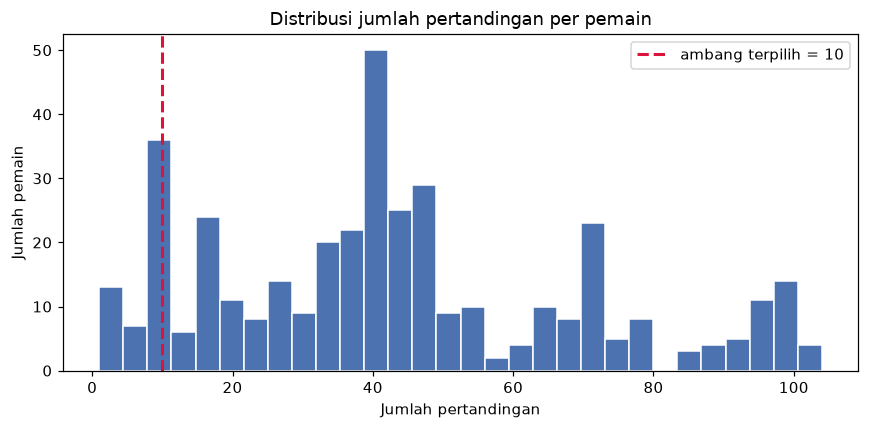

Pemain final: 352 (dari 394)

position  bot  jng  mid  sup  top
league                           
LCK        11   11   12   11   12
LCP        11   12   10    8   10
LEC        10   10   10   11   10
LPL        20   20   17   20   17
LTA N       9    9    9    8   10
LTA S       9   12   14   10    9


In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(agg["n_games"], bins=30, color="#4C72B0", edgecolor="white")
ax.axvline(MIN_GAMES, color="crimson", ls="--", lw=2, label=f"ambang terpilih = {MIN_GAMES}")
ax.set(title="Distribusi jumlah pertandingan per pemain",
       xlabel="Jumlah pertandingan", ylabel="Jumlah pemain")
ax.legend(); plt.tight_layout(); plt.savefig("fig_01_min_games.png", bbox_inches="tight"); plt.show()

P = agg[agg["n_games"] >= MIN_GAMES].reset_index(drop=True).copy()
print(f"Pemain final: {len(P)} (dari {len(agg)})")
print()
print(P.groupby(["league", "position"]).size().unstack(fill_value=0).to_string())

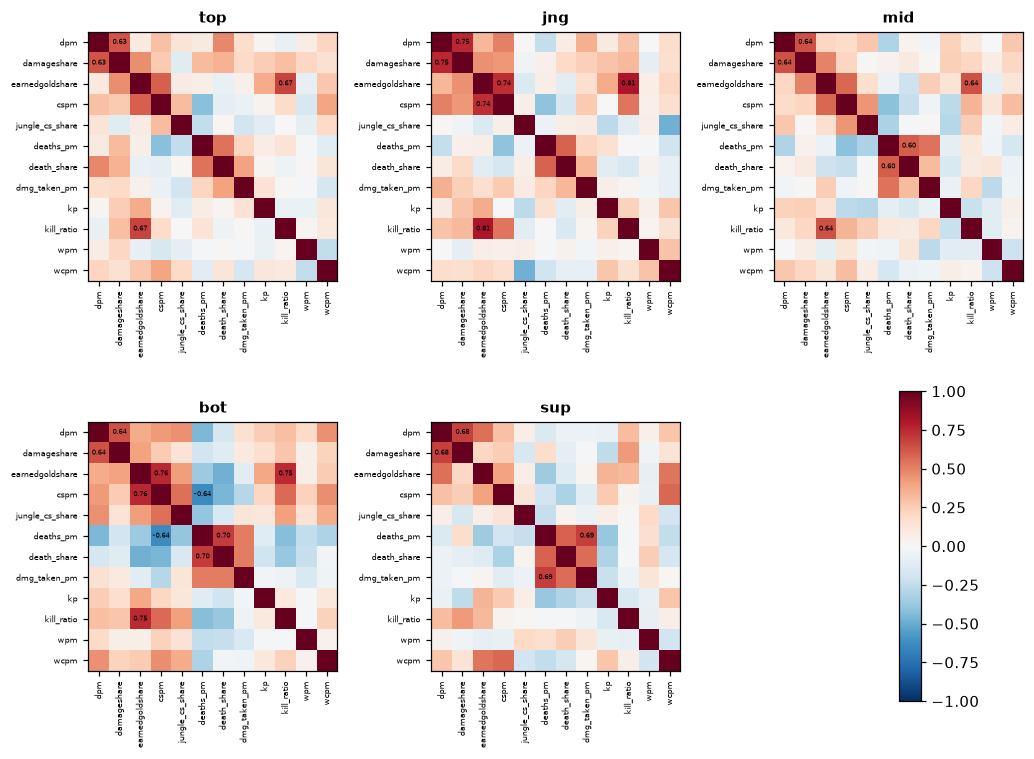

Pasangan dengan |r| >= 0,60 (indikasi redundansi):
  top: [('dpm', 'damageshare', np.float64(0.63)), ('earnedgoldshare', 'kill_ratio', np.float64(0.67))]
  jng: [('dpm', 'damageshare', np.float64(0.75)), ('earnedgoldshare', 'cspm', np.float64(0.74)), ('earnedgoldshare', 'kill_ratio', np.float64(0.81))]
  mid: [('dpm', 'damageshare', np.float64(0.64)), ('earnedgoldshare', 'kill_ratio', np.float64(0.64)), ('deaths_pm', 'death_share', np.float64(0.6))]
  bot: [('dpm', 'damageshare', np.float64(0.64)), ('earnedgoldshare', 'cspm', np.float64(0.76)), ('earnedgoldshare', 'kill_ratio', np.float64(0.75)), ('cspm', 'deaths_pm', np.float64(-0.64)), ('deaths_pm', 'death_share', np.float64(0.7))]
  sup: [('dpm', 'damageshare', np.float64(0.68)), ('deaths_pm', 'dmg_taken_pm', np.float64(0.69))]


In [11]:
fig, ax = plt.subplots(2, 3, figsize=(9.5, 7.2))
for i, role in enumerate(ROLES):
    a = ax[i // 3][i % 3]
    Cm_ = P[P["position"] == role][FEATURES].corr()
    im = a.imshow(Cm_, cmap="RdBu_r", vmin=-1, vmax=1)
    a.set_xticks(range(len(FEATURES))); a.set_xticklabels(FEATURES, rotation=90, fontsize=5.5)
    a.set_yticks(range(len(FEATURES))); a.set_yticklabels(FEATURES, fontsize=5.5)
    a.set_title(role, fontsize=10, fontweight="bold")
    for x in range(len(FEATURES)):
        for y in range(len(FEATURES)):
            if x != y and abs(Cm_.iloc[x, y]) >= 0.60:
                a.text(y, x, f"{Cm_.iloc[x, y]:.2f}", ha="center", va="center", fontsize=4.6)
ax[1][2].axis("off")
fig.colorbar(im, ax=ax[1][2], fraction=0.5, aspect=14)
plt.tight_layout()
plt.savefig("fig_02_korelasi.png", dpi=200, bbox_inches="tight"); plt.show()

print("Pasangan dengan |r| >= 0,60 (indikasi redundansi):")
for role in ROLES:
    Cm_ = P[P["position"] == role][FEATURES].corr()
    hits = [(Cm_.index[i], Cm_.columns[j], round(Cm_.iloc[i, j], 2))
            for i in range(len(Cm_)) for j in range(i + 1, len(Cm_))
            if abs(Cm_.iloc[i, j]) >= 0.60]
    print(f"  {role:>3}: {hits if hits else 'tidak ada'}")

In [12]:
def reliabilitas_belah_dua(frame_game, kolom_kunci, seed=RANDOM_STATE):
    """Reliabilitas belah-dua dgn koreksi Spearman-Brown, dihitung per role.

    Pertandingan tiap pemain dibelah acak jadi dua bagian, nilai variabel
    dihitung terpisah pada tiap bagian dengan aturan agregasi yang sama
    seperti model utama, lalu keduanya dikorelasikan antar-pemain.
    """
    f = frame_game.copy()
    rng = np.random.default_rng(seed)
    f["_acak"] = rng.random(len(f))
    f["_bagian"] = f.groupby(kolom_kunci)["_acak"].rank(pct=True) > 0.5

    def nilai(sub):
        gg = sub.groupby(kolom_kunci)
        out = pd.DataFrame(index=gg.size().index)
        for nama, kolom in KOLOM_SIAP_PAKAI.items():
            out[nama] = gg[kolom].mean()
        for nama, (pemb, peny) in VARIABEL_TURUNAN.items():
            out[nama] = gg[pemb].sum() / gg[peny].sum().replace(0, np.nan)
        return out

    hasil = {}
    for role in ROLES:
        s = f[f["position"] == role]
        A, B = nilai(s[~s["_bagian"]]), nilai(s[s["_bagian"]])
        kol = {}
        for v in FEATURES:
            j = pd.concat([A[v].rename("a"), B[v].rename("b")], axis=1).dropna()
            r = j["a"].corr(j["b"])
            kol[v] = 2 * r / (1 + r) if pd.notna(r) else np.nan   # Spearman-Brown
        hasil[role] = kol
    return pd.DataFrame(hasil)

In [13]:
ROLES = ["top", "jng", "mid", "bot", "sup"]     # dipakai juga di bagian berikutnya
d_final = d.merge(P[KEY], on=KEY, how="inner")  # hanya pemain yg lolos ambang

rel = reliabilitas_belah_dua(d_final, KEY)
rel["rata-rata"] = rel.mean(axis=1)
rel = rel.loc[FEATURES]

print("Reliabilitas belah-dua (terkoreksi Spearman-Brown)")
print("Mendekati 1 = variasi antar-pemain merupakan sinyal stabil.\n")
print(rel.round(2).to_string())

lemah = rel.index[rel["rata-rata"] < 0.5].tolist()
print()
print("Variabel dengan reliabilitas rata-rata di bawah 0,50:", lemah if lemah else "tidak ada")

Reliabilitas belah-dua (terkoreksi Spearman-Brown)
Mendekati 1 = variasi antar-pemain merupakan sinyal stabil.

                  top   jng   mid   bot   sup  rata-rata
dpm              0.67  0.66  0.68  0.79  0.56       0.67
damageshare      0.52  0.69  0.45  0.73  0.36       0.55
earnedgoldshare  0.69  0.84  0.42  0.81  0.60       0.67
cspm             0.85  0.85  0.66  0.88  0.87       0.82
jungle_cs_share  0.83  0.60  0.77  0.74  0.26       0.64
deaths_pm        0.75  0.63  0.67  0.66  0.76       0.70
death_share      0.60  0.68  0.58  0.63  0.83       0.66
dmg_taken_pm     0.71  0.70  0.65  0.60  0.70       0.67
kp               0.12  0.23  0.23  0.16  0.29       0.21
kill_ratio       0.60  0.48 -0.23  0.67  0.28       0.36
wpm              0.96  0.94  0.88  0.95  0.91       0.93
wcpm             0.89  0.71  0.82  0.86  0.85       0.83

Variabel dengan reliabilitas rata-rata di bawah 0,50: ['kp', 'kill_ratio']


In [14]:
gg = d_final.groupby(KEY)
uji = pd.DataFrame({
    "kills_per_menit":   gg["kills"].sum()   / gg["mins"].sum(),
    "assists_per_menit": gg["assists"].sum() / gg["mins"].sum(),
    "kp":                gg["kills_assists"].sum() / gg["teamkills"].sum(),
    "kill_ratio":        gg["kills"].sum() / gg["kills_assists"].sum(),
    "tempo_kill_tim":    gg["teamkills"].sum() / gg["mins"].sum(),
}).reset_index()

print("Korelasi terhadap tempo kill tim (makin tinggi = makin mengukur tim, bukan pemain)\n")
print(f"{'role':>5} | {'kills/mnt':>10} | {'assists/mnt':>12} | {'kp':>7} | {'kill_ratio':>11}")
print("-" * 58)
for role in ROLES:
    s = uji[uji["position"] == role]
    print(f"{role:>5} | {s['kills_per_menit'].corr(s['tempo_kill_tim']):>10.2f} | "
          f"{s['assists_per_menit'].corr(s['tempo_kill_tim']):>12.2f} | "
          f"{s['kp'].corr(s['tempo_kill_tim']):>7.2f} | "
          f"{s['kill_ratio'].corr(s['tempo_kill_tim']):>11.2f}")
print()
print("kp dan kill_ratio nyaris tidak berkorelasi dgn tempo tim -- itu memang tujuannya.")
print("Laju per menit sangat berkorelasi, sehingga kestabilannya menyesatkan bagi")
print("penelitian yang menyasar gaya individu.")

Korelasi terhadap tempo kill tim (makin tinggi = makin mengukur tim, bukan pemain)

 role |  kills/mnt |  assists/mnt |      kp |  kill_ratio
----------------------------------------------------------
  top |       0.60 |         0.90 |   -0.22 |       -0.48
  jng |       0.75 |         0.93 |   -0.19 |        0.16
  mid |       0.84 |         0.89 |    0.09 |       -0.01
  bot |       0.87 |         0.86 |    0.16 |        0.23
  sup |       0.52 |         0.97 |    0.16 |       -0.10

kp dan kill_ratio nyaris tidak berkorelasi dgn tempo tim -- itu memang tujuannya.
Laju per menit sangat berkorelasi, sehingga kestabilannya menyesatkan bagi
penelitian yang menyasar gaya individu.


In [15]:
Z_COLS = [f"{c}_z" for c in FEATURES]
for c in FEATURES:
    P[f"{c}_z"] = P.groupby("position")[c].transform(lambda x: (x - x.mean()) / x.std())

chk = P.groupby("position")[Z_COLS].agg(["mean", "std"])
print("Sanity check (mean harus ~0, std harus ~1):")
print(chk.iloc[:, :6].round(3).to_string())
print()
print("Proporsi variansi yang dijelaskan LIGA (eta-squared) -- sinyal yang kini DIPERTAHANKAN:")
rows = []
for role in ROLES:
    s = P[P["position"] == role]
    row = {"role": role}
    for c in FEATURES:
        gg  = s.groupby("league")[c]
        sst = ((s[c] - s[c].mean()) ** 2).sum()
        ssb = (gg.count() * (gg.mean() - s[c].mean()) ** 2).sum()
        row[c] = ssb / sst
    rows.append(row)
print(pd.DataFrame(rows).set_index("role").round(3).to_string())

Sanity check (mean harus ~0, std harus ~1):
         dpm_z      damageshare_z      earnedgoldshare_z     
          mean  std          mean  std              mean  std
position                                                     
bot       -0.0  1.0          -0.0  1.0              -0.0  1.0
jng       -0.0  1.0          -0.0  1.0              -0.0  1.0
mid       -0.0  1.0           0.0  1.0              -0.0  1.0
sup       -0.0  1.0          -0.0  1.0               0.0  1.0
top        0.0  1.0           0.0  1.0              -0.0  1.0

Proporsi variansi yang dijelaskan LIGA (eta-squared) -- sinyal yang kini DIPERTAHANKAN:
        dpm  damageshare  earnedgoldshare   cspm  jungle_cs_share  deaths_pm  death_share  dmg_taken_pm     kp  kill_ratio    wpm   wcpm
role                                                                                                                                    
top   0.123        0.198            0.105  0.031            0.113      0.139        0.223        

In [16]:
pca_models, X_red = {}, {}
loadings_all = {}

for role in ROLES:
    m = P["position"] == role
    X = P.loc[m, Z_COLS].values

    p_full = PCA(random_state=RANDOM_STATE).fit(X)
    cum    = np.cumsum(p_full.explained_variance_ratio_)
    n_comp = int(np.searchsorted(cum, PCA_VAR_TARGET) + 1)

    p = PCA(n_components=n_comp, random_state=RANDOM_STATE).fit(X)
    X_red[role]      = p.transform(X)
    pca_models[role] = p
    loadings_all[role] = pd.DataFrame(p.components_.T,
                                      index=FEATURES,
                                      columns=[f"PC{i+1}" for i in range(n_comp)])
    P.loc[m, "pc1"] = X_red[role][:, 0]
    P.loc[m, "pc2"] = X_red[role][:, 1]
    print(f"{role:>3}: {n_comp} komponen dipertahankan "
          f"({cum[n_comp-1]:.1%} variansi) | PC1={p.explained_variance_ratio_[0]:.1%} "
          f"PC2={p.explained_variance_ratio_[1]:.1%}")

top: 6 komponen dipertahankan (82.0% variansi) | PC1=23.1% PC2=19.3%
jng: 6 komponen dipertahankan (84.6% variansi) | PC1=28.2% PC2=16.4%
mid: 6 komponen dipertahankan (83.6% variansi) | PC1=23.9% PC2=18.0%
bot: 6 komponen dipertahankan (85.4% variansi) | PC1=36.7% PC2=15.4%
sup: 6 komponen dipertahankan (82.7% variansi) | PC1=26.5% PC2=19.0%


In [17]:
for role in ROLES:
    print(f"\n=== {role.upper()} — loading PC1..PC3 ===")
    print(loadings_all[role].iloc[:, :3].round(2).to_string())
    for pc in loadings_all[role].columns[:3]:
        s = loadings_all[role][pc].sort_values()
        print(f"  {pc}: (-) {', '.join(s.index[:3])}  <-->  (+) {', '.join(s.index[-3:][::-1])}")


=== TOP — loading PC1..PC3 ===
                  PC1   PC2   PC3
dpm              0.37  0.15 -0.45
damageshare      0.49  0.18  0.03
earnedgoldshare  0.46 -0.24  0.37
cspm             0.34 -0.42 -0.15
jungle_cs_share  0.06 -0.30 -0.39
deaths_pm        0.14  0.47  0.16
death_share      0.25  0.42 -0.32
dmg_taken_pm     0.15  0.34  0.03
kp               0.20  0.03  0.20
kill_ratio       0.29 -0.13  0.49
wpm             -0.02  0.16  0.11
wcpm             0.26 -0.25 -0.26
  PC1: (-) wpm, jungle_cs_share, deaths_pm  <-->  (+) damageshare, earnedgoldshare, dpm
  PC2: (-) cspm, jungle_cs_share, wcpm  <-->  (+) deaths_pm, death_share, dmg_taken_pm
  PC3: (-) dpm, jungle_cs_share, death_share  <-->  (+) kill_ratio, earnedgoldshare, kp

=== JNG — loading PC1..PC3 ===
                  PC1   PC2   PC3
dpm              0.38  0.16  0.22
damageshare      0.39  0.25  0.03
earnedgoldshare  0.47 -0.01 -0.08
cspm             0.44 -0.09  0.30
jungle_cs_share -0.10  0.17  0.53
deaths_pm       -0.09  0.51

In [18]:
def fit_kmeans(X, k, seed=RANDOM_STATE):
    return KMeans(n_clusters=k, init="k-means++", n_init=20, random_state=seed).fit(X)

def find_elbow_k(ks, wcss):
    """Deteksi titik siku otomatis: jarak tegak lurus terbesar ke garis
    yang menghubungkan titik pertama dan terakhir pada kurva ternormalisasi
    (metode Kneedle, Satopaa et al., 2011)."""
    k = np.asarray(ks, float); w = np.asarray(wcss, float)
    kn = (k - k.min()) / (k.max() - k.min())
    wn = (w - w.min()) / (w.max() - w.min())
    p1, p2 = np.array([kn[0], wn[0]]), np.array([kn[-1], wn[-1]])
    v = p2 - p1; ln = np.linalg.norm(v)
    dist = [abs(v[0] * (p1[1] - y) - v[1] * (p1[0] - x)) / ln for x, y in zip(kn, wn)]
    return int(ks[int(np.argmax(dist))])

def gap_statistic(X, k, n_ref=25, seed=RANDOM_STATE):
    """Gap statistic dengan acuan uniform pada bounding box data (Tibshirani et al., 2001)."""
    rng = np.random.default_rng(seed)
    lo, hi = X.min(0), X.max(0)
    wk = np.log(fit_kmeans(X, k).inertia_)
    refs = []
    for _ in range(n_ref):
        Xr = rng.uniform(lo, hi, size=X.shape)
        refs.append(np.log(fit_kmeans(Xr, k).inertia_))
    refs = np.array(refs)
    sk = refs.std() * np.sqrt(1 + 1 / n_ref)
    return refs.mean() - wk, sk

def bootstrap_ari(X, k, n_boot=N_BOOTSTRAP, frac=BOOT_FRAC, seed=RANDOM_STATE):
    """Stabilitas: bandingkan label penuh vs label hasil clustering subsample."""
    base = fit_kmeans(X, k).labels_
    rng  = np.random.default_rng(seed)
    n    = len(X); out = []
    for b in range(n_boot):
        idx = rng.choice(n, int(n * frac), replace=False)
        lb  = fit_kmeans(X[idx], k, seed=b).labels_
        out.append(adjusted_rand_score(base[idx], lb))
    return float(np.mean(out)), float(np.std(out))

In [19]:
diag = {}
for role in ROLES:
    X = X_red[role]; n = len(X)
    rows = []
    for k in K_RANGE:
        km  = fit_kmeans(X, k)
        lab = km.labels_
        gap, sk = gap_statistic(X, k)
        ari_m, ari_s = bootstrap_ari(X, k)
        rows.append({
            "K": k,
            "WCSS": km.inertia_,
            "silhouette": silhouette_score(X, lab),
            "davies_bouldin": davies_bouldin_score(X, lab),
            "calinski_harabasz": calinski_harabasz_score(X, lab),
            "gap": gap, "gap_sk": sk,
            "ARI_boot": ari_m, "ARI_sd": ari_s,
            "min_cluster": int(np.bincount(lab).min()),
            "min_cluster_pct": np.bincount(lab).min() / n,
        })
    diag[role] = pd.DataFrame(rows).set_index("K")
    print(f"\n=== {role.upper()} (n={n}) ===")
    print(diag[role].round(3).to_string())


=== TOP (n=68) ===
      WCSS  silhouette  davies_bouldin  calinski_harabasz    gap  gap_sk  ARI_boot  ARI_sd  min_cluster  min_cluster_pct
K                                                                                                                       
2  541.014       0.171           1.975             14.427  0.531   0.047     0.304   0.223           26            0.382
3  450.873       0.164           1.703             15.022  0.519   0.044     0.694   0.157           13            0.191
4  397.514       0.159           1.580             14.048  0.514   0.050     0.624   0.136           11            0.162
5  358.881       0.191           1.374             13.183  0.508   0.048     0.613   0.139            3            0.044
6  331.015       0.158           1.446             12.297  0.503   0.048     0.486   0.103            4            0.059
7  302.930       0.163           1.451             11.959  0.510   0.045     0.506   0.128            6            0.088
8  288.455  

In [20]:
optimal_k, elbow_k = {}, {}
print("Penerapan aturan keputusan:\n")
for role in ROLES:
    t = diag[role]
    elbow_k[role] = find_elbow_k(list(K_RANGE), t["WCSS"].values)
    cand = t[(t.index >= K_MIN_MEANING) &
             (t["ARI_boot"] >= ARI_THRESHOLD) &
             (t["min_cluster_pct"] >= 0.05) &
             (t["min_cluster"] >= 5)]
    if len(cand):
        k_sel, why = int(cand.index.max()), f"K terbesar dengan ARI>={ARI_THRESHOLD} & cluster terkecil layak"
    else:
        sub = t[t.index >= K_MIN_MEANING]
        k_sel, why = int(sub["ARI_boot"].idxmax()), "fallback: ARI tertinggi (tidak ada K yang lolos ambang)"
    if role in K_OVERRIDE:
        k_sel, why = K_OVERRIDE[role], f"OVERRIDE MANUAL (aturan menunjuk K={k_sel})"
    optimal_k[role] = k_sel
    print(f"  {role:>3}: K={k_sel}  (ARI={t.loc[k_sel,'ARI_boot']:.3f}, "
          f"silhouette={t.loc[k_sel,'silhouette']:.3f}, "
          f"cluster terkecil={t.loc[k_sel,'min_cluster']}) | elbow menunjuk K={elbow_k[role]} | {why}")
print("\nK final per role:", optimal_k)

Penerapan aturan keputusan:

  top: K=4  (ARI=0.624, silhouette=0.159, cluster terkecil=11) | elbow menunjuk K=4 | K terbesar dengan ARI>=0.6 & cluster terkecil layak
  jng: K=3  (ARI=0.597, silhouette=0.177, cluster terkecil=16) | elbow menunjuk K=4 | fallback: ARI tertinggi (tidak ada K yang lolos ambang)
  mid: K=5  (ARI=0.560, silhouette=0.159, cluster terkecil=6) | elbow menunjuk K=5 | fallback: ARI tertinggi (tidak ada K yang lolos ambang)
  bot: K=3  (ARI=0.744, silhouette=0.181, cluster terkecil=16) | elbow menunjuk K=4 | K terbesar dengan ARI>=0.6 & cluster terkecil layak
  sup: K=4  (ARI=0.552, silhouette=0.156, cluster terkecil=9) | elbow menunjuk K=5 | fallback: ARI tertinggi (tidak ada K yang lolos ambang)

K final per role: {'top': 4, 'jng': 3, 'mid': 5, 'bot': 3, 'sup': 4}


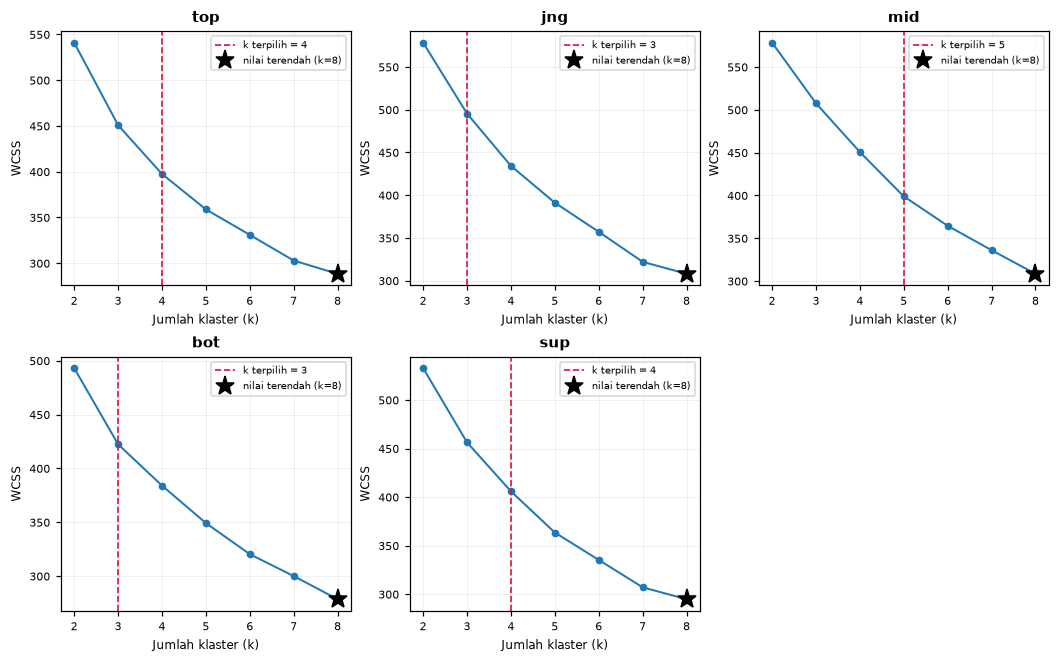

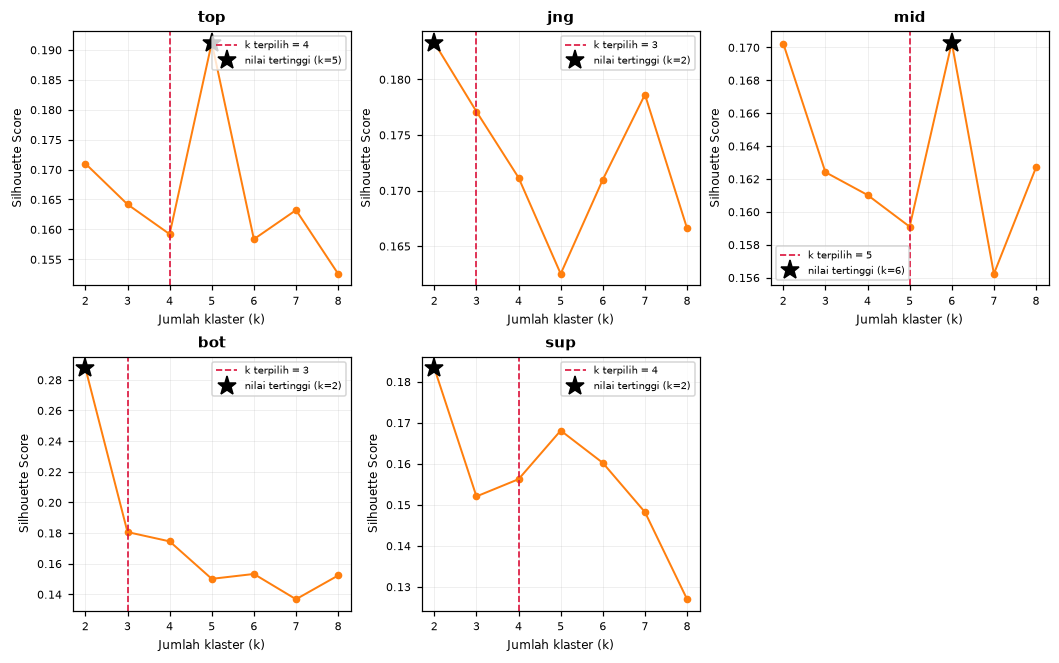

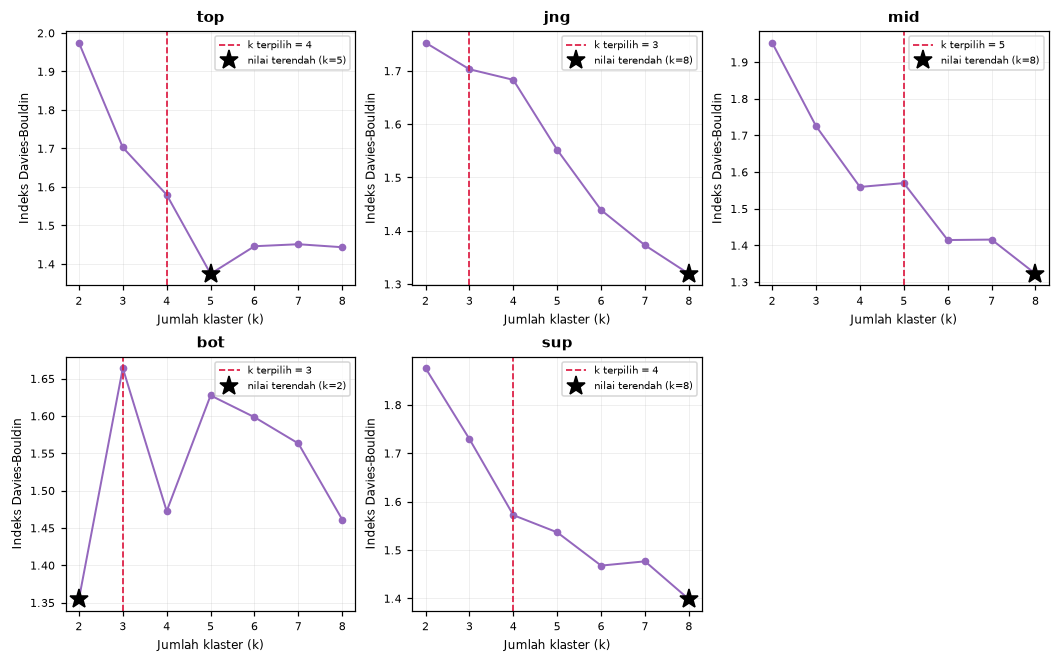

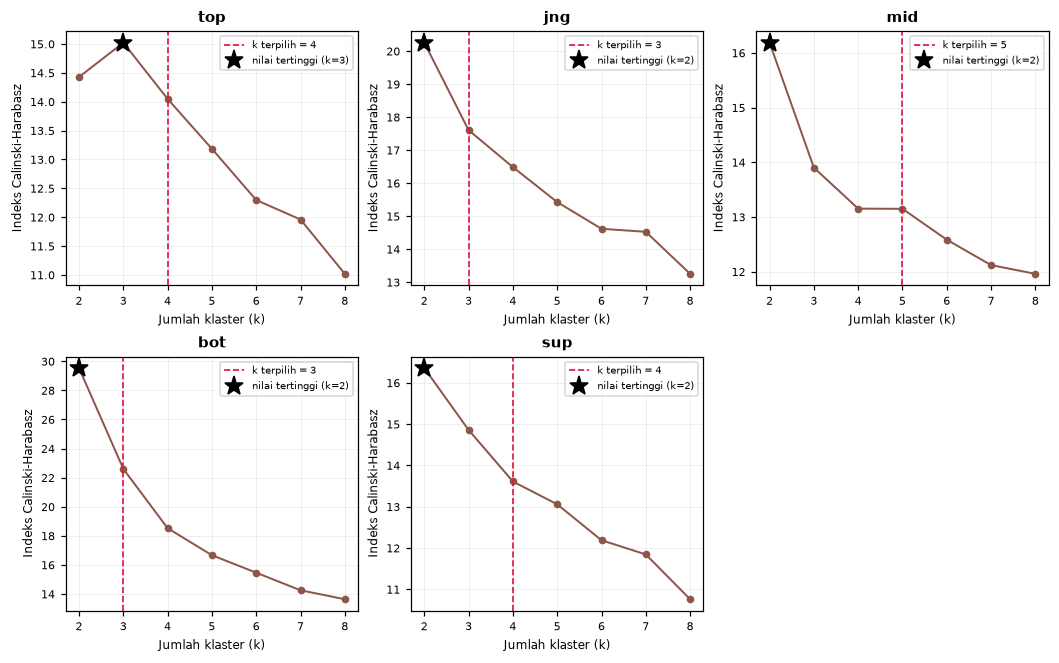

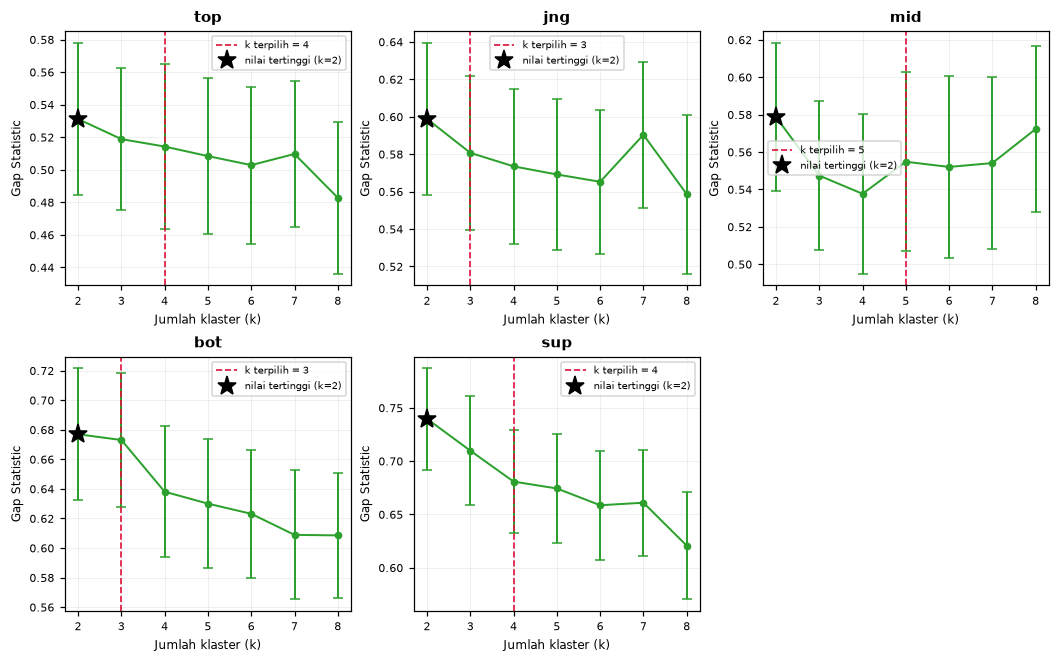

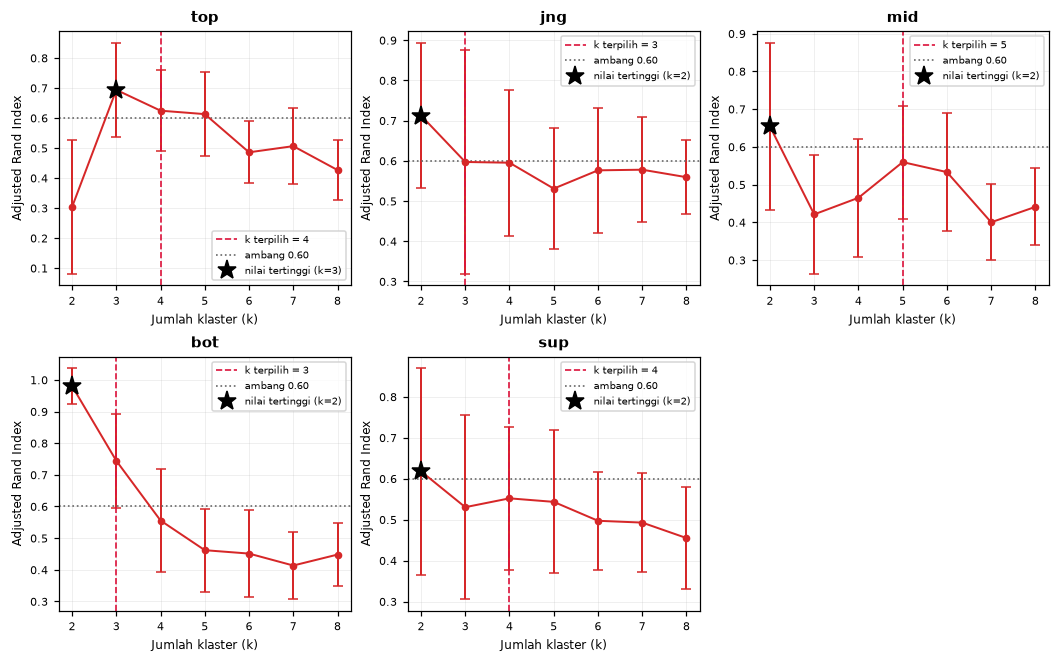

In [21]:
def kurva_metrik(kolom, judul_y, berkas, warna, galat=None, ambang=None, arah="maks"):
    """Satu berkas gambar untuk satu metrik, memuat kelima peran dalam grid 2x3."""
    fig, ax = plt.subplots(2, 3, figsize=(9.6, 6.0))
    for i, role in enumerate(ROLES):
        a = ax[i // 3][i % 3]
        s = diag[role].reset_index().sort_values("K")
        if galat:
            a.errorbar(s["K"], s[kolom], yerr=s[galat], marker="o", ms=4, lw=1.3,
                       color=warna, capsize=3)
        else:
            a.plot(s["K"], s[kolom], marker="o", ms=4, lw=1.3, color=warna)
        k = optimal_k[role]
        a.axvline(k, color="crimson", ls="--", lw=1.1, label=f"k terpilih = {k}")
        if ambang is not None:
            a.axhline(ambang, color="dimgrey", ls=":", lw=1.1, label=f"ambang {ambang:.2f}")
        idx = s[kolom].idxmax() if arah == "maks" else s[kolom].idxmin()
        lbl = "nilai tertinggi" if arah == "maks" else "nilai terendah"
        a.plot(s.loc[idx, "K"], s.loc[idx, kolom], marker="*", ms=13, color="black",
               zorder=5, ls="none", label=f"{lbl} (k={int(s.loc[idx, 'K'])})")
        a.set_title(role, fontsize=10, fontweight="bold")
        a.set_xlabel("Jumlah klaster (k)", fontsize=8)
        a.set_ylabel(judul_y, fontsize=8)
        a.tick_params(labelsize=7.5); a.grid(alpha=.25, lw=.5)
        a.legend(fontsize=6.6, loc="best")
    ax[1][2].axis("off")
    plt.tight_layout(pad=0.6)
    plt.savefig(berkas, dpi=200, bbox_inches="tight"); plt.show()

# Satu metrik satu gambar agar setiap kurva dapat dicermati terpisah.
kurva_metrik("WCSS",              "WCSS",                      "fig_03a_wcss.png",       "tab:blue",   arah="min")
kurva_metrik("silhouette",        "Silhouette Score",          "fig_03b_silhouette.png", "tab:orange")
kurva_metrik("davies_bouldin",    "Indeks Davies-Bouldin",     "fig_03c_davies.png",     "tab:purple", arah="min")
kurva_metrik("calinski_harabasz", "Indeks Calinski-Harabasz",  "fig_03d_calinski.png",   "tab:brown")
kurva_metrik("gap",               "Gap Statistic",             "fig_03e_gap.png",        "tab:green",  galat="gap_sk")
kurva_metrik("ARI_boot",          "Adjusted Rand Index",       "fig_03f_ari.png",        "tab:red",
             galat="ARI_sd", ambang=ARI_THRESHOLD)

In [22]:
models = {}
P["cluster"] = -1

for role in ROLES:
    m = P["position"] == role
    X = X_red[role]
    km = fit_kmeans(X, optimal_k[role])
    lab = km.labels_

    order  = np.argsort([X[lab == c, 0].mean() for c in range(optimal_k[role])])
    remap  = {old: new for new, old in enumerate(order)}
    lab    = np.array([remap[l] for l in lab])

    P.loc[m, "cluster"] = lab
    models[role] = km
    print(f"{role:>3} (K={optimal_k[role]}): ukuran cluster = {np.bincount(lab).tolist()}")

P["role_cluster"] = P["position"] + "_" + P["cluster"].astype(str)

top (K=4): ukuran cluster = [20, 19, 18, 11]
jng (K=3): ukuran cluster = [24, 34, 16]
mid (K=5): ukuran cluster = [21, 13, 18, 14, 6]
bot (K=3): ukuran cluster = [16, 33, 21]
sup (K=4): ukuran cluster = [20, 9, 22, 17]


In [23]:
print("Centroid dalam skala Z (untuk radar chart & interpretasi):\n")
centroids_z = P.groupby(["position", "cluster"])[Z_COLS].mean()
centroids_z.columns = [c[:-2] for c in centroids_z.columns]
print(centroids_z.round(2).to_string())

Centroid dalam skala Z (untuk radar chart & interpretasi):

                   dpm  damageshare  earnedgoldshare  cspm  jungle_cs_share  deaths_pm  death_share  dmg_taken_pm    kp  kill_ratio   wpm  wcpm
position cluster                                                                                                                               
bot      0       -0.97        -0.74            -1.13 -1.18            -0.53       1.27         1.04          0.68 -0.62       -1.08 -0.35 -0.81
         1        0.03         0.05            -0.12  0.01            -0.36      -0.35        -0.31         -0.46  0.09       -0.06  0.24  0.05
         2        0.69         0.49             1.05  0.89             0.97      -0.41        -0.31          0.21  0.33        0.91 -0.11  0.53
jng      0       -0.71        -0.86            -1.03 -0.92             0.08       0.10         0.14         -0.28 -0.44       -0.86 -0.35 -0.43
         1        0.32         0.45             0.47  0.28             0.12 

In [24]:
print("Centroid dalam skala ASLI (untuk pelaporan di naskah):\n")
centroids_raw = P.groupby(["position", "cluster"])[FEATURES].mean()
print(centroids_raw.round(3).to_string())

Centroid dalam skala ASLI (untuk pelaporan di naskah):

                      dpm  damageshare  earnedgoldshare   cspm  jungle_cs_share  deaths_pm  death_share  dmg_taken_pm     kp  kill_ratio    wpm   wcpm
position cluster                                                                                                                                      
bot      0        631.273        0.261            0.247  8.847            0.031      0.095        0.189       513.681  0.687       0.378  0.394  0.278
         1        703.030        0.274            0.257  9.288            0.033      0.067        0.158       472.372  0.710       0.427  0.424  0.324
         2        749.986        0.281            0.269  9.617            0.048      0.066        0.158       496.913  0.717       0.474  0.406  0.350
jng      0        379.134        0.150            0.185  6.106            0.895      0.093        0.209      1152.042  0.722       0.244  0.305  0.326
         1        430.991        0.168

In [25]:
cmp_rows = []
for role in ROLES:
    X = X_red[role]; k = optimal_k[role]
    lab_km   = fit_kmeans(X, k).labels_
    lab_ward = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(X)
    lab_gmm  = GaussianMixture(n_components=k, covariance_type="full",
                               n_init=10, random_state=RANDOM_STATE).fit_predict(X)
    cmp_rows.append({
        "role": role, "K": k,
        "sil_kmeans": silhouette_score(X, lab_km),
        "sil_ward":   silhouette_score(X, lab_ward),
        "sil_gmm":    silhouette_score(X, lab_gmm),
        "ARI_km_vs_ward": adjusted_rand_score(lab_km, lab_ward),
        "ARI_km_vs_gmm":  adjusted_rand_score(lab_km, lab_gmm),
    })
cmp_df = pd.DataFrame(cmp_rows).set_index("role")
print(cmp_df.round(3).to_string())
print()
print(f"Rata-rata kesepakatan K-Means vs Ward : {cmp_df['ARI_km_vs_ward'].mean():.3f}")
print(f"Rata-rata kesepakatan K-Means vs GMM  : {cmp_df['ARI_km_vs_gmm'].mean():.3f}")
print("\nPanduan tafsir ARI: >0.75 sangat sepakat | 0.50-0.75 sepakat sedang | <0.50 lemah")

      K  sil_kmeans  sil_ward  sil_gmm  ARI_km_vs_ward  ARI_km_vs_gmm
role                                                                 
top   4       0.159     0.156    0.072           0.361          0.193
jng   3       0.177     0.156    0.084           0.212          0.299
mid   5       0.159     0.165    0.142           0.623          0.232
bot   3       0.181     0.176    0.175           0.658          0.363
sup   4       0.156     0.115    0.117           0.381          0.422

Rata-rata kesepakatan K-Means vs Ward : 0.447
Rata-rata kesepakatan K-Means vs GMM  : 0.302

Panduan tafsir ARI: >0.75 sangat sepakat | 0.50-0.75 sepakat sedang | <0.50 lemah


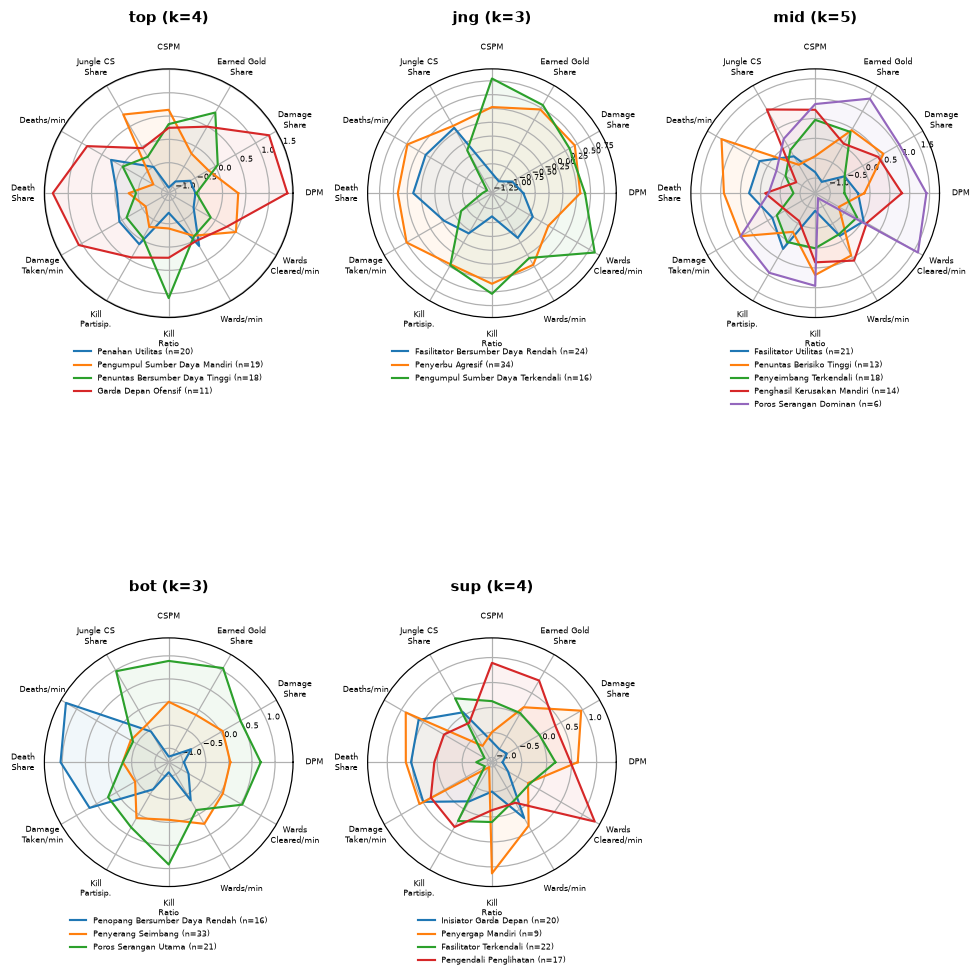

In [26]:
LABELS = ["DPM", "Damage\nShare", "Earned Gold\nShare", "CSPM", "Jungle CS\nShare",
          "Deaths/min", "Death\nShare", "Damage\nTaken/min", "Kill\nPartisip.",
          "Kill\nRatio", "Wards/min", "Wards\nCleared/min"]
ang = np.linspace(0, 2 * np.pi, len(FEATURES), endpoint=False).tolist(); ang += ang[:1]

fig, ax = plt.subplots(2, 3, figsize=(10.5, 9.4), subplot_kw=dict(polar=True))
for i, role in enumerate(ROLES):
    a = ax[i // 3][i % 3]
    cen = P[P["position"] == role].groupby("cluster")[Z_COLS].mean()
    for cid, row in cen.iterrows():
        v = row.tolist() + [row.tolist()[0]]
        n = int((P["role_cluster"] == f"{role}_{cid}").sum())
        nama = CLUSTER_NAMES.get(f"{role}_{cid}", f"cluster {cid}")
        a.plot(ang, v, lw=1.4, label=f"{nama} (n={n})")
        a.fill(ang, v, alpha=0.06)
    a.set_xticks(ang[:-1]); a.set_xticklabels(LABELS, fontsize=5.2)
    a.tick_params(axis="y", labelsize=5.5)
    a.set_title(f"{role} (k={optimal_k[role]})", fontsize=10, fontweight="bold", pad=14)
    a.legend(loc="upper center", bbox_to_anchor=(0.5, -0.09), fontsize=5.4, frameon=False)
ax[1][2].axis("off")
plt.subplots_adjust(hspace=0.62, wspace=0.30, top=0.94, bottom=0.05)
plt.savefig("fig_04_radar.png", dpi=200); plt.show()

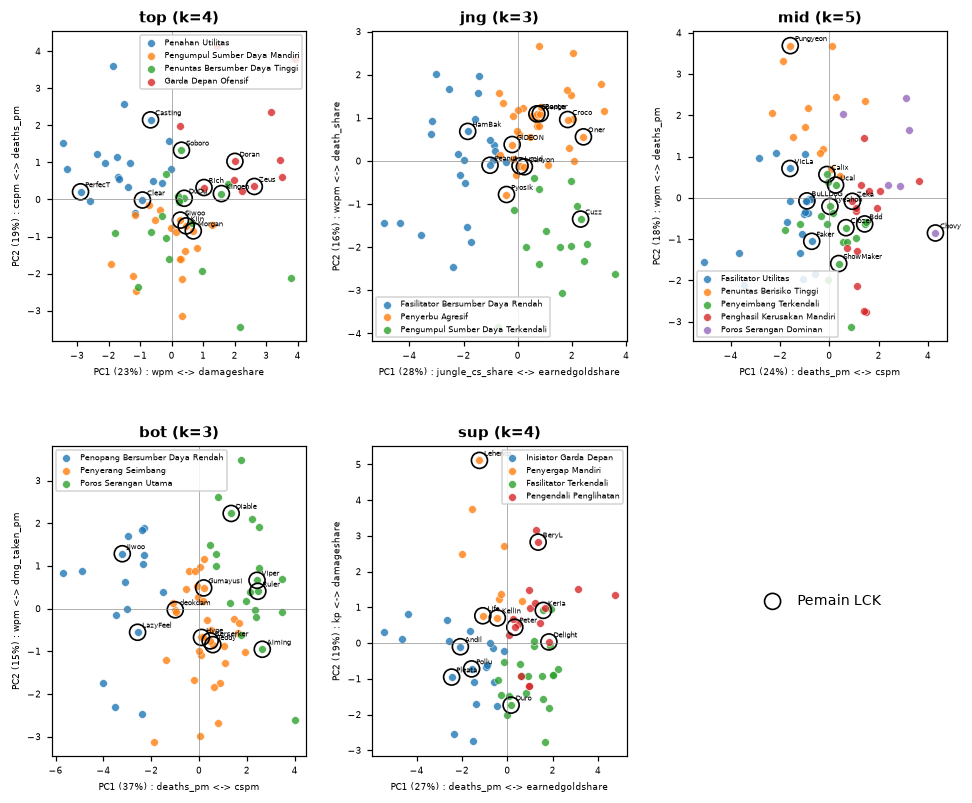

In [27]:
fig, ax = plt.subplots(2, 3, figsize=(10.5, 7.4))
for i, role in enumerate(ROLES):
    a = ax[i // 3][i % 3]
    s = P[P["position"] == role]
    ld = loadings_all[role]
    for cl in sorted(s["cluster"].unique()):
        d_ = s[s["cluster"] == cl]
        nama = CLUSTER_NAMES.get(f"{role}_{cl}", f"cluster {cl}")
        a.scatter(d_["pc1"], d_["pc2"], s=26, alpha=.8, label=nama,
                  edgecolor="white", lw=.4)
    lck = s[s["league"] == FOCUS_LEAGUE]
    a.scatter(lck["pc1"], lck["pc2"], facecolors="none", edgecolors="black", s=110, lw=1.1)
    for _, x in lck.iterrows():
        a.annotate(x["playername"], (x["pc1"], x["pc2"]), fontsize=4.6,
                   xytext=(3, 3), textcoords="offset points")
    a.axhline(0, color="grey", lw=.4); a.axvline(0, color="grey", lw=.4)
    a.set_title(f"{role} (k={optimal_k[role]})", fontsize=10, fontweight="bold")
    a.set_xlabel(f"PC1 ({pca_models[role].explained_variance_ratio_[0]:.0%}) : "
                 f"{ld['PC1'].idxmin()} <-> {ld['PC1'].idxmax()}", fontsize=5.6)
    a.set_ylabel(f"PC2 ({pca_models[role].explained_variance_ratio_[1]:.0%}) : "
                 f"{ld['PC2'].idxmin()} <-> {ld['PC2'].idxmax()}", fontsize=5.6)
    a.tick_params(labelsize=6)
    a.legend(fontsize=5, loc="best", frameon=True, framealpha=.85)
ax[1][2].axis("off")
ax[1][2].scatter([], [], facecolors="none", edgecolors="black", s=110, lw=1.1,
                 label=f"Pemain {FOCUS_LEAGUE}")
ax[1][2].legend(loc="center", fontsize=9, frameon=False)
plt.subplots_adjust(hspace=0.34, wspace=0.26, top=0.95, bottom=0.06)
plt.savefig("fig_05_pca_scatter.png", dpi=200); plt.show()

In [28]:
MIN_PICKS = 12
champ_val = {}

for role in ROLES:
    m  = P["position"] == role
    mm = d.merge(P.loc[m, ["playerid", "cluster"]], on="playerid", how="inner")
    base = mm["champion"].value_counts(normalize=True)
    print(f"\n{'='*78}\n{role.upper()}")
    for cid in sorted(P.loc[m, 'cluster'].unique()):
        sub  = mm[mm["cluster"] == cid]
        freq = sub["champion"].value_counts(normalize=True)
        cnt  = sub["champion"].value_counts()
        lift = (freq / base).dropna()
        lift = lift[cnt.reindex(lift.index).fillna(0) >= MIN_PICKS].sort_values(ascending=False)
        champ_val[f"{role}_{cid}"] = lift
        print(f"  cluster {cid} (n={int((P['role_cluster']==f'{role}_{cid}').sum())} pemain, "
              f"{len(sub)} pertandingan)")
        print(f"     OVER-PICK : " + ", ".join(f"{i} ({v:.2f}x)" for i, v in lift.head(6).items()))
        print(f"     UNDER-PICK: " + ", ".join(f"{i} ({v:.2f}x)" for i, v in lift.tail(4).items()))


TOP
  cluster 0 (n=20 pemain, 952 pertandingan)
     OVER-PICK : Udyr (1.81x), Ornn (1.45x), Galio (1.35x), Sion (1.25x), Rumble (1.15x), Gragas (1.14x)
     UNDER-PICK: Aatrox (0.94x), Gwen (0.89x), Ambessa (0.87x), Jayce (0.71x)
  cluster 1 (n=19 pemain, 1081 pertandingan)
     OVER-PICK : Cho'Gath (1.48x), Gnar (1.29x), Aurora (1.29x), Yorick (1.19x), Renekton (1.16x), Jayce (1.15x)
     UNDER-PICK: Galio (0.86x), Gragas (0.86x), K'Sante (0.79x), Jax (0.76x)
  cluster 2 (n=18 pemain, 744 pertandingan)
     OVER-PICK : K'Sante (1.42x), Ambessa (1.25x), Jax (1.19x), Aatrox (1.14x), Jayce (1.07x), Gwen (1.00x)
     UNDER-PICK: Sion (0.86x), Renekton (0.81x), Yorick (0.78x), Gnar (0.75x)
  cluster 3 (n=11 pemain, 551 pertandingan)
     OVER-PICK : Nidalee (3.62x), Aurora (1.72x), Jax (1.24x), Gwen (1.13x), Jayce (1.12x), Aatrox (1.07x)
     UNDER-PICK: Yorick (0.86x), Ornn (0.85x), Sion (0.74x), K'Sante (0.61x)

JNG
  cluster 0 (n=24 pemain, 823 pertandingan)
     OVER-PICK : Ivern (2.

In [29]:
def deskripsi(zrow, thr=0.5):
    out = []
    for f, v in zrow.items():
        nm = f[:-2]
        if v >= thr:  out.append(f"{nm} TINGGI ({v:+.2f})")
        elif v <= -thr: out.append(f"{nm} RENDAH ({v:+.2f})")
    return out or ["(mendekati rata-rata di semua fitur)"]

for role in ROLES:
    cen = P[P["position"] == role].groupby("cluster")[Z_COLS].mean()
    print(f"\n--- {role.upper()} ---")
    for cid, row in cen.iterrows():
        key = f"{role}_{cid}"
        n   = int((P["role_cluster"] == key).sum())
        top = ", ".join(champ_val[key].head(4).index) if key in champ_val else "-"
        print(f"  {key} (n={n})")
        print(f"     statistik: " + "; ".join(deskripsi(row)))
        print(f"     champion : {top}")


--- TOP ---
  top_0 (n=20)
     statistik: dpm RENDAH (-0.58); damageshare RENDAH (-0.62); earnedgoldshare RENDAH (-0.86); cspm RENDAH (-1.03); jungle_cs_share RENDAH (-0.51); kill_ratio RENDAH (-0.73); wcpm RENDAH (-0.54)
     champion : Udyr, Ornn, Galio, Sion
  top_1 (n=19)
     statistik: cspm TINGGI (+0.63); jungle_cs_share TINGGI (+0.79); deaths_pm RENDAH (-0.77); dmg_taken_pm RENDAH (-0.59); wcpm TINGGI (+0.51)
     champion : Cho'Gath, Gnar, Aurora, Yorick
  top_2 (n=18)
     statistik: dpm RENDAH (-0.56); earnedgoldshare TINGGI (+0.84); kill_ratio TINGGI (+1.10)
     champion : K'Sante, Ambessa, Jax, Aatrox
  top_3 (n=11)
     statistik: dpm TINGGI (+1.39); damageshare TINGGI (+1.33); deaths_pm TINGGI (+0.87); death_share TINGGI (+1.33); dmg_taken_pm TINGGI (+1.07)
     champion : Nidalee, Aurora, Jax, Gwen

--- JNG ---
  jng_0 (n=24)
     statistik: dpm RENDAH (-0.71); damageshare RENDAH (-0.86); earnedgoldshare RENDAH (-1.03); cspm RENDAH (-0.92); kill_ratio RENDAH (-0.86)


In [30]:
P["playstyle"] = P["role_cluster"].map(CLUSTER_NAMES)

belum   = sorted(set(P["role_cluster"]) - set(CLUSTER_NAMES))
berlebih = sorted(set(CLUSTER_NAMES) - set(P["role_cluster"]))

if belum:
    print("PERINGATAN -- klaster berikut belum dinamai:", belum)
    print("Aturan keputusan menghasilkan k yang berbeda dari saat kamus disusun.")
    print("Sesuaikan CLUSTER_NAMES pada sel konfigurasi.")
    P["playstyle"] = P["playstyle"].fillna(P["role_cluster"])
if berlebih:
    print("CATATAN -- nama berikut tidak terpakai:", berlebih)
if not belum and not berlebih:
    print(f"Seluruh {len(CLUSTER_NAMES)} profil terpetakan dengan tepat.")

print()
print(P.groupby(["position", "cluster", "playstyle"]).size().rename("n_pemain").to_string())

Seluruh 19 profil terpetakan dengan tepat.

position  cluster  playstyle                        
bot       0        Penopang Bersumber Daya Rendah       16
          1        Penyerang Seimbang                   33
          2        Poros Serangan Utama                 21
jng       0        Fasilitator Bersumber Daya Rendah    24
          1        Penyerbu Agresif                     34
          2        Pengumpul Sumber Daya Terkendali     16
mid       0        Fasilitator Utilitas                 21
          1        Penuntas Berisiko Tinggi             13
          2        Penyeimbang Terkendali               18
          3        Penghasil Kerusakan Mandiri          14
          4        Poros Serangan Dominan                6
sup       0        Inisiator Garda Depan                20
          1        Penyergap Mandiri                     9
          2        Fasilitator Terkendali               22
          3        Pengendali Penglihatan               17
top       0       

In [31]:
from scipy.stats import chi2_contingency

def cramers_v(ct):
    chi2 = chi2_contingency(ct)[0]
    n = ct.values.sum()
    return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

def perm_test(sub, n_perm=5000, seed=RANDOM_STATE):
    obs = chi2_contingency(pd.crosstab(sub["league"], sub["cluster"]))[0]
    rng = np.random.default_rng(seed)
    lg  = sub["league"].values.copy(); cl = sub["cluster"].values
    null = []
    for _ in range(n_perm):
        rng.shuffle(lg)
        null.append(chi2_contingency(pd.crosstab(pd.Series(lg), pd.Series(cl)))[0])
    return obs, (np.sum(np.array(null) >= obs) + 1) / (n_perm + 1)

for role in ROLES:
    sub = P[P["position"] == role]
    ct  = pd.crosstab(sub["league"], sub["cluster"])
    chi2, p_asym, dof, _ = chi2_contingency(ct)
    obs, p_perm = perm_test(sub)
    print(f"\n=== {role.upper()} ===")
    print(f"chi2={chi2:.2f} dof={dof} | p(asimtotik)={p_asym:.4f} | "
          f"p(permutasi)={p_perm:.4f} | Cramer's V={cramers_v(ct):.3f}")
    print(pd.crosstab(sub["league"], sub["cluster"], normalize="index").round(2).to_string())


=== TOP ===
chi2=16.33 dof=15 | p(asimtotik)=0.3605 | p(permutasi)=0.3841 | Cramer's V=0.283
cluster     0     1     2     3
league                         
LCK      0.25  0.25  0.25  0.25
LCP      0.40  0.30  0.20  0.10
LEC      0.10  0.40  0.40  0.10
LPL      0.41  0.29  0.24  0.06
LTA N    0.50  0.10  0.30  0.10
LTA S    0.00  0.33  0.22  0.44

=== JNG ===
chi2=21.05 dof=10 | p(asimtotik)=0.0208 | p(permutasi)=0.0196 | Cramer's V=0.377
cluster     0     1     2
league                   
LCK      0.18  0.73  0.09
LCP      0.25  0.58  0.17
LEC      0.70  0.00  0.30
LPL      0.10  0.60  0.30
LTA N    0.44  0.44  0.11
LTA S    0.50  0.25  0.25

=== MID ===
chi2=24.37 dof=20 | p(asimtotik)=0.2268 | p(permutasi)=0.2288 | Cramer's V=0.291
cluster     0     1     2     3     4
league                               
LCK      0.25  0.08  0.50  0.08  0.08
LCP      0.30  0.10  0.20  0.30  0.10
LEC      0.00  0.30  0.30  0.40  0.00
LPL      0.41  0.12  0.35  0.06  0.06
LTA N    0.22  0.22  0.11 

In [32]:
lck = P[P["league"] == FOCUS_LEAGUE].sort_values(["position", "cluster", "playername"])
print(f"Pemain {FOCUS_LEAGUE} dan profil gaya bermainnya ({len(lck)} pemain):\n")
print(lck[["playername", "teamname", "position", "cluster", "playstyle", "n_games"]]
      .to_string(index=False))

Pemain LCK dan profil gaya bermainnya (57 pemain):

playername            teamname position  cluster                         playstyle  n_games
     Jiwoo   Nongshim RedForce      bot        0    Penopang Bersumber Daya Rendah       63
  LazyFeel          Kiwoom DRX      bot        0    Penopang Bersumber Daya Rendah       24
 Berserker          DN SOOPers      bot        1                Penyerang Seimbang       73
  Gumayusi                  T1      bot        1                Penyerang Seimbang       62
      Hype        HANJIN BRION      bot        1                Penyerang Seimbang       69
     Teddy          Kiwoom DRX      bot        1                Penyerang Seimbang       52
   deokdam          KT Rolster      bot        1                Penyerang Seimbang       65
    Aiming           Dplus Kia      bot        2              Poros Serangan Utama       77
    Diable           BNK FEARX      bot        2              Poros Serangan Utama       75
     Ruler               Gen

In [33]:
rows = []
for role in ROLES:
    m   = P["position"] == role
    X   = X_red[role]
    sub = P.loc[m].reset_index(drop=True)
    cen = np.array([X[sub["cluster"].values == c].mean(0) for c in sorted(sub["cluster"].unique())])
    dist = np.linalg.norm(X - cen[sub["cluster"].values], axis=1)
    sub  = sub.assign(dist_centroid=dist)
    rows.append(sub)
P_dist = pd.concat(rows, ignore_index=True)

f = P_dist[P_dist["league"] == FOCUS_LEAGUE].copy()
f["rank_dlm_cluster"] = f.groupby("role_cluster")["dist_centroid"].rank()
print(f"Pemain {FOCUS_LEAGUE} paling representatif untuk tiap profil (jarak terkecil ke centroid):\n")
print(f.sort_values(["position", "cluster", "dist_centroid"])
       [["playername", "position", "cluster", "playstyle", "dist_centroid"]]
       .round(2).to_string(index=False))

Pemain LCK paling representatif untuk tiap profil (jarak terkecil ke centroid):

playername position  cluster                         playstyle  dist_centroid
  LazyFeel      bot        0    Penopang Bersumber Daya Rendah           1.76
     Jiwoo      bot        0    Penopang Bersumber Daya Rendah           1.82
      Hype      bot        1                Penyerang Seimbang           1.24
 Berserker      bot        1                Penyerang Seimbang           1.72
   deokdam      bot        1                Penyerang Seimbang           1.77
  Gumayusi      bot        1                Penyerang Seimbang           1.90
     Teddy      bot        1                Penyerang Seimbang           2.36
     Ruler      bot        2              Poros Serangan Utama           1.57
     Viper      bot        2              Poros Serangan Utama           1.82
    Aiming      bot        2              Poros Serangan Utama           2.38
    Diable      bot        2              Poros Serangan Utam

In [34]:
export_cols = (["playername", "playerid", "league", "position", "teamname", "n_games"]
               + FEATURES + Z_COLS
               + ["cluster", "role_cluster", "playstyle", "pc1", "pc2"])
P[export_cols].sort_values(["position", "cluster", "league"]) \
              .to_csv("out_hasil_clustering_pemain.csv", index=False)

ringkasan = (P.groupby(["position", "cluster", "role_cluster", "playstyle"])
               .agg(n_pemain=("playername", "count"),
                    **{f"{c}_mean": (c, "mean") for c in FEATURES},
                    **{f"{c}_z": (f"{c}_z", "mean") for c in FEATURES})
               .reset_index())
ringkasan.to_csv("out_ringkasan_cluster.csv", index=False)

pd.concat({r: diag[r] for r in ROLES}, names=["role"]).to_csv("out_diagnostik_k.csv")
cmp_df.to_csv("out_perbandingan_algoritma.csv")
pd.concat({r: loadings_all[r] for r in ROLES}, names=["role"]).to_csv("out_pca_loadings.csv")

In [35]:
# --- champion lift per cluster (bahan penamaan & validasi domain) ---
baris_champ = []
for role in ROLES:
    m  = P["position"] == role
    mm = d.merge(P.loc[m, ["playerid", "cluster"]], on="playerid", how="inner")
    base = mm["champion"].value_counts(normalize=True)
    for cid in sorted(P.loc[m, "cluster"].unique()):
        sub  = mm[mm["cluster"] == cid]
        freq = sub["champion"].value_counts(normalize=True)
        cnt  = sub["champion"].value_counts()
        for champ in cnt.index:
            if cnt[champ] >= MIN_PICKS:
                baris_champ.append({
                    "role": role, "cluster": int(cid), "role_cluster": f"{role}_{cid}",
                    "champion": champ, "n_pick": int(cnt[champ]),
                    "share_cluster": round(float(freq[champ]), 4),
                    "share_role": round(float(base[champ]), 4),
                    "lift": round(float(freq[champ] / base[champ]), 3),
                })
champ_df = (pd.DataFrame(baris_champ)
            .sort_values(["role", "cluster", "lift"], ascending=[True, True, False]))
champ_df.to_csv("out_champion_lift.csv", index=False)

In [36]:
# --- tabel reliabilitas variabel ---
rel.to_csv("out_reliabilitas_variabel.csv")

print("Tersimpan:")
for f_ in ["out_hasil_clustering_pemain.csv", "out_ringkasan_cluster.csv",
           "out_diagnostik_k.csv", "out_perbandingan_algoritma.csv", "out_pca_loadings.csv",
           "out_champion_lift.csv", "out_reliabilitas_variabel.csv"]:
    print("  -", f_)
print("Gambar: fig_01, fig_02, fig_03a-fig_03f, fig_04, fig_05 (.png)")

Tersimpan:
  - out_hasil_clustering_pemain.csv
  - out_ringkasan_cluster.csv
  - out_diagnostik_k.csv
  - out_perbandingan_algoritma.csv
  - out_pca_loadings.csv
  - out_champion_lift.csv
  - out_reliabilitas_variabel.csv
Gambar: fig_01, fig_02, fig_03a-fig_03f, fig_04, fig_05 (.png)


In [37]:
PA = P.copy()
ZA = [f"{c}_za" for c in FEATURES]
for c in FEATURES:
    PA[f"{c}_za"] = PA.groupby(["league", "position"])[c].transform(lambda x: (x - x.mean()) / x.std())

print(f"{'role':>4} | {'ARI global vs per-liga':>22} | {'Cramers V (global)':>18} | {'Cramers V (per-liga)':>20}")
print("-" * 78)
for role in ROLES:
    m  = PA["position"] == role
    Xa = PCA(n_components=X_red[role].shape[1], random_state=RANDOM_STATE) \
            .fit_transform(PA.loc[m, ZA].values)
    lab_a = fit_kmeans(Xa, optimal_k[role]).labels_
    lab_g = PA.loc[m, "cluster"].values
    sub_a = PA.loc[m].assign(cl=lab_a)
    v_g = cramers_v(pd.crosstab(PA.loc[m, "league"], lab_g))
    v_a = cramers_v(pd.crosstab(sub_a["league"], sub_a["cl"]))
    print(f"{role:>4} | {adjusted_rand_score(lab_g, lab_a):>22.3f} | {v_g:>18.3f} | {v_a:>20.3f}")
print()
print("Cramer's V mengukur keterkaitan liga dengan keanggotaan cluster.")
print("Nilai yang jauh lebih rendah pada versi per-liga membuktikan bahwa normalisasi")
print("per-liga menghapus sinyal antar-region yang justru menjadi objek RM#4.")

role | ARI global vs per-liga | Cramers V (global) | Cramers V (per-liga)
------------------------------------------------------------------------------
 top |                  0.529 |              0.283 |                0.147
 jng |                  0.405 |              0.377 |                0.155
 mid |                  0.402 |              0.291 |                0.170
 bot |                  0.525 |              0.165 |                0.131
 sup |                  0.376 |              0.320 |                0.189

Cramer's V mengukur keterkaitan liga dengan keanggotaan cluster.
Nilai yang jauh lebih rendah pada versi per-liga membuktikan bahwa normalisasi
per-liga menghapus sinyal antar-region yang justru menjadi objek RM#4.


In [38]:
TEMPO = ["golddiffat15", "xpdiffat15", "csdiffat15"]
d5 = d[d["league"] != "LPL"].dropna(subset=TEMPO)
g5 = d5.groupby(KEY)
B = pd.DataFrame({t: g5[t].mean() for t in TEMPO}).reset_index()

PB = P[P["league"] != "LPL"].merge(B, on=KEY, how="inner")
FB = FEATURES + TEMPO
ZB = [f"{c}_zb" for c in FB]
for c in FB:
    PB[f"{c}_zb"] = PB.groupby("position")[c].transform(lambda x: (x - x.mean()) / x.std())

print(f"n pemain (tanpa LPL): {len(PB)}\n")
print(f"{'role':>4} | {'n':>4} | {'komponen':>9} | {'K':>2} | {'silhouette':>10} | {'ARI vs model utama':>19}")
print("-" * 72)
for role in ROLES:
    m = PB["position"] == role
    X = PB.loc[m, ZB].values
    pf  = PCA(random_state=RANDOM_STATE).fit(X)
    nc  = int(np.searchsorted(np.cumsum(pf.explained_variance_ratio_), PCA_VAR_TARGET) + 1)
    Xb  = PCA(n_components=nc, random_state=RANDOM_STATE).fit_transform(X)
    k   = optimal_k[role]
    lab = fit_kmeans(Xb, k).labels_
    print(f"{role:>4} | {m.sum():>4} | {nc:>9} | {k:>2} | {silhouette_score(Xb, lab):>10.3f} | "
          f"{adjusted_rand_score(PB.loc[m, 'cluster'].values, lab):>19.3f}")
print()
print("Cara membaca ARI di atas (bandingkan model utama vs model + fitur tempo):")
print("  ARI >= 0.60 : struktur cluster relatif bertahan -> pengecualian fitur tempo aman")
print("  ARI 0.30-0.60: sebagian struktur berubah -> laporkan sebagai keterbatasan di Bab V")
print("  ARI <  0.30 : dimensi tempo membawa informasi gaya yang berbeda; pertimbangkan")
print("                menjadikannya analisis pendamping khusus untuk role tersebut")

n pemain (tanpa LPL): 258

role |    n |  komponen |  K | silhouette |  ARI vs model utama
------------------------------------------------------------------------
 top |   51 |         6 |  4 |      0.193 |               0.527
 jng |   54 |         6 |  3 |      0.192 |               0.421
 mid |   55 |         6 |  5 |      0.174 |               0.608
 bot |   50 |         6 |  3 |      0.213 |               0.772
 sup |   48 |         7 |  4 |      0.118 |               0.351

Cara membaca ARI di atas (bandingkan model utama vs model + fitur tempo):
  ARI >= 0.60 : struktur cluster relatif bertahan -> pengecualian fitur tempo aman
  ARI 0.30-0.60: sebagian struktur berubah -> laporkan sebagai keterbatasan di Bab V
  ARI <  0.30 : dimensi tempo membawa informasi gaya yang berbeda; pertimbangkan
                menjadikannya analisis pendamping khusus untuk role tersebut


In [39]:
dA = d_final.copy()
for nama, (pemb, peny) in VARIABEL_TURUNAN.items():
    dA[nama] = dA[pemb] / dA[peny].replace(0, np.nan)

gA = dA.groupby(KEY)
ALT = pd.DataFrame(index=gA.size().index)
for nama, kolom in KOLOM_SIAP_PAKAI.items():
    ALT[nama] = gA[kolom].mean()
for nama in VARIABEL_TURUNAN:
    ALT[nama] = gA[nama].mean()
ALT = ALT.reset_index()

print(f"Model utama (dua jalur) : {len(P)} pemain")
print(f"Alternatif (satu jalur) : {len(ALT)} pemain")


Model utama (dua jalur) : 352 pemain
Alternatif (satu jalur) : 352 pemain


In [40]:
bd = P[KEY + FEATURES].merge(ALT, on=KEY, suffixes=("_utama", "_alt"))
baris = []
for f in FEATURES:
    u, a = bd[f + "_utama"], bd[f + "_alt"]
    rel_ = ((u - a).abs() / u.abs().replace(0, np.nan) * 100)
    baris.append({"variabel": f, "utama": u.mean(), "alternatif": a.mean(),
                  "selisih rata2 (%)": rel_.mean(), "selisih maks (%)": rel_.max()})
print(pd.DataFrame(baris).round(3).to_string(index=False))
print()
print("Tujuh variabel pertama identik nol karena diperlakukan sama pada kedua versi;")
print("perbedaan hanya muncul pada lima variabel turunan.")

       variabel   utama  alternatif  selisih rata2 (%)  selisih maks (%)
            dpm 511.957     511.957              0.000             0.000
    damageshare   0.200       0.200              0.000             0.000
earnedgoldshare   0.200       0.200              0.000             0.000
           cspm   6.690       6.690              0.000             0.000
jungle_cs_share   0.206       0.205              6.325            37.768
      deaths_pm   0.088       0.089              1.716             6.690
    death_share   0.202       0.201              5.635            25.078
   dmg_taken_pm 736.813     736.813              0.000             0.000
             kp   0.691       0.682              2.439            13.893
     kill_ratio   0.295       0.301              8.139            58.145
            wpm   0.671       0.671              0.000             0.000
           wcpm   0.301       0.301              0.000             0.000

Tujuh variabel pertama identik nol karena diperlak

In [41]:
print(f"{'role':>5} | {'ARI utama vs alt':>17} | {'beda klaster':>14} | "
      f"{'stabil utama':>12} | {'stabil alt':>11}")
print("-" * 74)
for role in ROLES:
    k  = optimal_k[role]
    sU = P[P["position"] == role]
    sA = ALT.set_index(KEY).loc[sU.set_index(KEY).index].reset_index()

    def ruang(frame):
        Z = ((frame[FEATURES] - frame[FEATURES].mean()) / frame[FEATURES].std()).values
        pf = PCA(random_state=RANDOM_STATE).fit(Z)
        nc = int(np.searchsorted(np.cumsum(pf.explained_variance_ratio_), PCA_VAR_TARGET) + 1)
        return PCA(n_components=nc, random_state=RANDOM_STATE).fit_transform(Z)

    XU, XA = ruang(sU), ruang(sA)
    labU, labA = fit_kmeans(XU, k).labels_, fit_kmeans(XA, k).labels_
    beda = len(labU) - pd.crosstab(labU, labA).values.max(1).sum()
    stU, _ = bootstrap_ari(XU, k, n_boot=60)
    stA, _ = bootstrap_ari(XA, k, n_boot=60)
    print(f"{role:>5} | {adjusted_rand_score(labU, labA):>17.3f} | "
          f"{beda:>4} dari {len(labU):<5} | {stU:>12.3f} | {stA:>11.3f}")
print()
print("Kolom stabilitas memakai kriteria yang sama dengan pemilihan k (bootstrap ARI).")

 role |  ARI utama vs alt |   beda klaster | stabil utama |  stabil alt
--------------------------------------------------------------------------


  top |             0.837 |    4 dari 68    |        0.609 |       0.574
  jng |             0.828 |    4 dari 74    |        0.586 |       0.603
  mid |             0.582 |   10 dari 72    |        0.556 |       0.579
  bot |             0.823 |    4 dari 70    |        0.731 |       0.832
  sup |             0.760 |    7 dari 68    |        0.528 |       0.578

Kolom stabilitas memakai kriteria yang sama dengan pemilihan k (bootstrap ARI).


In [42]:
def ruang_pca(frame, var):
    """Ruang komponen utama pada ambang variansi tertentu; kembalikan koordinat & jumlah komponen."""
    Z = ((frame[FEATURES] - frame[FEATURES].mean()) / frame[FEATURES].std()).values
    evr = PCA(random_state=RANDOM_STATE).fit(Z).explained_variance_ratio_
    m = int(np.searchsorted(np.cumsum(evr), var) + 1)
    return PCA(n_components=m, random_state=RANDOM_STATE).fit_transform(Z), m

# ---------- D.1  PCA_VAR_TARGET ----------
VAR_UJI = [0.70, 0.80, 0.90]
acuan = {r: fit_kmeans(ruang_pca(P[P["position"] == r], PCA_VAR_TARGET)[0],
                       optimal_k[r]).labels_ for r in ROLES}

print("D.1  Pengaruh ambang variansi PCA terhadap hasil klaster")
print("     (ARI dibandingkan terhadap konfigurasi yang dipakai)\n")
print(f"{'role':>5} | " + " | ".join(f"{'var ' + str(v):>20}" for v in VAR_UJI))
print("-" * 74)
for r in ROLES:
    sel = []
    for v in VAR_UJI:
        X, m = ruang_pca(P[P["position"] == r], v)
        lab = fit_kmeans(X, optimal_k[r]).labels_
        tanda = " *" if abs(v - PCA_VAR_TARGET) < 1e-9 else "  "
        sel.append(f"{m} komp, ARI {adjusted_rand_score(acuan[r], lab):.2f}{tanda}")
    print(f"{r:>5} | " + " | ".join(f"{s:>20}" for s in sel))
print("\n* = konfigurasi yang dipakai. ARI rendah berarti hasil sensitif terhadap parameter ini.")

D.1  Pengaruh ambang variansi PCA terhadap hasil klaster
     (ARI dibandingkan terhadap konfigurasi yang dipakai)

 role |              var 0.7 |              var 0.8 |              var 0.9
--------------------------------------------------------------------------
  top |   5 komp, ARI 0.88   |   6 komp, ARI 1.00 * |   8 komp, ARI 0.97  
  jng |   5 komp, ARI 0.91   |   6 komp, ARI 1.00 * |   7 komp, ARI 1.00  
  mid |   5 komp, ARI 0.51   |   6 komp, ARI 1.00 * |   8 komp, ARI 0.92  
  bot |   4 komp, ARI 0.63   |   6 komp, ARI 1.00 * |   7 komp, ARI 1.00  
  sup |   5 komp, ARI 0.77   |   6 komp, ARI 1.00 * |   8 komp, ARI 0.82  

* = konfigurasi yang dipakai. ARI rendah berarti hasil sensitif terhadap parameter ini.


In [43]:
FRAC_UJI = [0.5, 0.7, 0.8, 0.9]
BOOT_UJI = [25, 50, 100, 200]

print("D.2a  Pengaruh fraksi subsampel terhadap nilai kestabilan\n")
print(f"{'role':>5} | " + " | ".join(f"{'frac ' + str(f):>12}" for f in FRAC_UJI))
print("-" * 66)
for r in ROLES:
    X, _ = ruang_pca(P[P["position"] == r], PCA_VAR_TARGET)
    nilai = [bootstrap_ari(X, optimal_k[r], n_boot=40, frac=f)[0] for f in FRAC_UJI]
    print(f"{r:>5} | " + " | ".join(f"{v:>12.3f}" for v in nilai))
print("\nSelisih antar-fraksi menunjukkan bahwa nilai kestabilan tidak bermakna absolut;")
print("angka tersebut hanya dapat ditafsirkan bersama fraksi subsampel yang dipakai.")

print("\n\nD.2b  Apakah jumlah replikasi bootstrap sudah memadai?")
print("      (nilai rata-rata dan galat bakunya)\n")
print(f"{'role':>5} | " + " | ".join(f"{'B=' + str(b):>15}" for b in BOOT_UJI))
print("-" * 74)
for r in ROLES:
    X, _ = ruang_pca(P[P["position"] == r], PCA_VAR_TARGET)
    sel = []
    for b in BOOT_UJI:
        m, s = bootstrap_ari(X, optimal_k[r], n_boot=b, frac=BOOT_FRAC)
        sel.append(f"{m:.3f} +/-{s / np.sqrt(b):.3f}")
    print(f"{r:>5} | " + " | ".join(f"{x:>15}" for x in sel))
print("\nGalat baku yang mengecil dan mendatar menandakan jumlah replikasi memadai.")

D.2a  Pengaruh fraksi subsampel terhadap nilai kestabilan

 role |     frac 0.5 |     frac 0.7 |     frac 0.8 |     frac 0.9
------------------------------------------------------------------
  top |        0.450 |        0.564 |        0.616 |        0.683
  jng |        0.473 |        0.488 |        0.556 |        0.626
  mid |        0.465 |        0.486 |        0.536 |        0.617
  bot |        0.591 |        0.714 |        0.721 |        0.817
  sup |        0.415 |        0.513 |        0.540 |        0.599

Selisih antar-fraksi menunjukkan bahwa nilai kestabilan tidak bermakna absolut;
angka tersebut hanya dapat ditafsirkan bersama fraksi subsampel yang dipakai.


D.2b  Apakah jumlah replikasi bootstrap sudah memadai?
      (nilai rata-rata dan galat bakunya)

 role |            B=25 |            B=50 |           B=100 |           B=200
--------------------------------------------------------------------------
  top |  0.582 +/-0.029 |  0.613 +/-0.020 |  0.624 +/-0.014 |  0.6

In [44]:
# ---------- D.3  ARI_THRESHOLD dan K_MIN_MEANING ----------
# Hitung sekali nilai ARI & ukuran klaster terkecil untuk seluruh k, lalu
# terapkan berbagai kombinasi aturan keputusan pada tabel yang sama.
tabel = {}
for r in ROLES:
    X, _ = ruang_pca(P[P["position"] == r], PCA_VAR_TARGET)
    n = len(X)
    tabel[r] = {k: (bootstrap_ari(X, k, n_boot=60, frac=BOOT_FRAC)[0],
                    int(np.bincount(fit_kmeans(X, k).labels_).min()), n)
                for k in K_RANGE}

print("D.3a  Nilai kestabilan dan ukuran klaster terkecil untuk setiap k\n")
for r in ROLES:
    n = tabel[r][list(K_RANGE)[0]][2]
    print(f"  {r} (n={n}): " + "  ".join(
        f"k={k}:{tabel[r][k][0]:.2f}(min {tabel[r][k][1]})" for k in K_RANGE))

def terapkan(role, ambang, kmin):
    lolos = [k for k in K_RANGE
             if k >= kmin and tabel[role][k][0] >= ambang
             and tabel[role][k][1] >= max(5, 0.05 * tabel[role][k][2])]
    if lolos:
        return str(max(lolos))
    cadangan = max([k for k in K_RANGE if k >= kmin], key=lambda k: tabel[role][k][0])
    return f"({cadangan})*"

print("\n\nD.3b  K yang terpilih pada berbagai kombinasi aturan keputusan\n")
print(f"{'aturan':>22}" + "".join(f"{r:>8}" for r in ROLES))
print("-" * 64)
for kmin in [2, K_MIN_MEANING]:
    for ambang in [0.50, ARI_THRESHOLD, 0.70]:
        dipakai = " <-" if (kmin == K_MIN_MEANING and abs(ambang - ARI_THRESHOLD) < 1e-9) else ""
        label = f"kmin={kmin} ambang={ambang:.2f}"
        print(f"{label:>22}" + "".join(f"{terapkan(r, ambang, kmin):>8}" for r in ROLES) + dipakai)
print("\n(*) tidak ada k yang lolos ambang, dipakai aturan cadangan ARI tertinggi")
print("(<-) konfigurasi yang dipakai pada model utama")
print()
print("Perhatikan baris kmin=2: bila k=2 diizinkan, sebagian role akan terpilih k=2 karena")
print("partisi dua kelompok memang paling stabil. Inilah alasan K_MIN_MEANING ditetapkan,")
print("dan alasannya bersifat substantif, bukan statistik.")

D.3a  Nilai kestabilan dan ukuran klaster terkecil untuk setiap k

  top (n=68): k=2:0.32(min 26)  k=3:0.69(min 13)  k=4:0.61(min 11)  k=5:0.60(min 3)  k=6:0.49(min 4)  k=7:0.50(min 6)  k=8:0.41(min 3)
  jng (n=74): k=2:0.70(min 29)  k=3:0.59(min 16)  k=4:0.59(min 13)  k=5:0.55(min 9)  k=6:0.56(min 10)  k=7:0.58(min 7)  k=8:0.56(min 6)
  mid (n=72): k=2:0.65(min 32)  k=3:0.42(min 14)  k=4:0.47(min 7)  k=5:0.56(min 6)  k=6:0.53(min 5)  k=7:0.40(min 6)  k=8:0.44(min 2)
  bot (n=70): k=2:0.99(min 21)  k=3:0.73(min 16)  k=4:0.56(min 10)  k=5:0.47(min 5)  k=6:0.46(min 6)  k=7:0.43(min 5)  k=8:0.46(min 3)
  sup (n=68): k=2:0.64(min 25)  k=3:0.52(min 15)  k=4:0.53(min 9)  k=5:0.53(min 9)  k=6:0.50(min 3)  k=7:0.50(min 6)  k=8:0.45(min 3)


D.3b  K yang terpilih pada berbagai kombinasi aturan keputusan

                aturan     top     jng     mid     bot     sup
----------------------------------------------------------------
    kmin=2 ambang=0.50       7       8       6       4       7
  

In [45]:
# ---------- D.4  Justifikasi jumlah variabel ----------
# Menguji klaim Bab II: yang menentukan mutu representasi adalah keseimbangan
# komposisi variabel antar-dimensi, bukan banyaknya variabel.
# Dibentuk himpunan pembanding berisi SELURUH kolom numerik tingkat pemain yang
# tersedia lengkap pada keenam liga, lalu diperlakukan dengan prosedur yang sama.

BUANG = {"year", "playoffs", "game", "patch", "participantid", "gameid", "result",
         "gamelength", "mins", "n", "teamkills", "teamdeaths", "doublekills",
         "triplekills", "quadrakills", "pentakills", "firstblood", "firstbloodkill",
         "firstbloodassist", "firstbloodvictim", "datacompleteness"}

num = [c for c in d.columns
       if pd.api.types.is_numeric_dtype(d[c]) and c not in BUANG]
lengkap = [c for c in num
           if d.groupby("league")[c].apply(lambda s: s.notna().mean()).min() > 0.99
           and d[c].std() > 0]
Q = d.groupby(KEY)[lengkap].mean()
Q = Q.loc[:, Q.std() > 0].dropna(axis=1).reset_index()
FITUR_LUAS = [c for c in Q.columns if c not in KEY]

print(f"D.4  Himpunan 12 variabel terpilih vs himpunan luas ({len(FITUR_LUAS)} variabel)\n")
print(f"{'peran':>6} {'n':>5} | {'PC1 (12 var)':>13} {'PC1 (luas)':>11} | selisih")
print("-" * 58)
for r in ROLES:
    A = P[P["position"] == r][FEATURES].dropna()
    a1 = PCA().fit(((A - A.mean()) / A.std()).values).explained_variance_ratio_[0]
    B = Q[Q["position"] == r][FITUR_LUAS].dropna()
    b1 = PCA().fit(((B - B.mean()) / B.std()).values).explained_variance_ratio_[0]
    print(f"{r:>6} {len(A):>5} | {a1 * 100:12.1f}% {b1 * 100:10.1f}% | {(b1 - a1) * 100:+6.1f} poin")

print("\nMuatan terbesar pada komponen pertama himpunan luas (peran jungle):")
B = Q[Q["position"] == "jng"][FITUR_LUAS].dropna()
m = PCA().fit(((B - B.mean()) / B.std()).values)
l = m.components_[0]
for j in np.argsort(-np.abs(l))[:6]:
    print(f"   {FITUR_LUAS[j]:<26} {l[j]:+.3f}")

print("\nKomponen pertama himpunan luas didominasi beberapa ukuran gold yang secara")
print("konstruk identik. Menambah variabel yang mengukur besaran yang sama tidak")
print("menambah informasi, melainkan menambah bobot pada dimensi yang sudah terwakili.")

D.4  Himpunan 12 variabel terpilih vs himpunan luas (27 variabel)

 peran     n |  PC1 (12 var)  PC1 (luas) | selisih
----------------------------------------------------------
   top    68 |         23.1%       38.5% |  +15.5 poin
   jng    74 |         28.2%       42.1% |  +13.9 poin
   mid    72 |         23.9%       32.7% |   +8.8 poin
   bot    70 |         36.7%       49.1% |  +12.4 poin
   sup    68 |         26.5%       34.2% |   +7.7 poin

Muatan terbesar pada komponen pertama himpunan luas (peran jungle):
   earnedgold                 +0.287
   totalgold                  +0.275
   earned gpm                 +0.273
   kills                      +0.260
   kills_assists              +0.256
   damagetochampions          +0.255

Komponen pertama himpunan luas didominasi beberapa ukuran gold yang secara
konstruk identik. Menambah variabel yang mengukur besaran yang sama tidak
menambah informasi, melainkan menambah bobot pada dimensi yang sudah terwakili.
